# Feature Engineering, Clustering, Experimentos A/B y Optimización de Hiperparámetros

El Sprint 1 identificó el mejor método de balanceo para cada modelo y descartó PCA como técnica de reducción de dimensionalidad. En este sprint se busca **enriquecer el espacio de features** con información geoquímica derivada y evaluar si los modelos pueden extraer más señal.

Se abordan tres ejes:

1. **Feature Engineering geoquímico:** log-ratios entre elementos no económicos (excluyendo metales de mena que no reflejan alteración/litología) y log-transformación de features asimétricas. Los ratios redundantes se filtran por correlación alta (|r| > 0.95), eliminando duplicados casi exactos de manera agnóstica al modelo.
2. **Clustering no supervisado:** KMeans, GMM y DBSCAN sobre los elementos no económicos en espacios RAW y LOG, generando features de agrupación que capturan dominios geoquímicos latentes.
3. **Optimización de hiperparámetros con Optuna:** búsqueda bayesiana (TPE) sobre el mejor set de features de cada modelo, maximizando F1\_CV.

**Criterio de decisión:** F1\_CV 5-fold estratificada. El hold-out se evalúa una sola vez al final, solo con fines informativos.

## Configuración

In [1]:
import warnings, os, json, itertools, time, platform, re
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import skew
from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve, silhouette_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ── Directorios de salida (misma estructura que Sprint 0) ──
OUT = 'outputs_sprint2'
DIR_DATA    = f'{OUT}/data'
DIR_MODELS  = f'{OUT}/models'
DIR_FIG     = f'{OUT}/figures'
DIR_TAB     = f'{OUT}/tables'
for d in (OUT, DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB):
    os.makedirs(d, exist_ok=True)

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())

# ── Estilo de impresión ──
def coral(texto):
    '''Resalta texto en color coral para resultados clave.'''
    return f'\033[38;2;255;127;80m{texto}\033[0m'

print('Carpetas listas:', OUT)

Carpetas listas: outputs_sprint2


## Versiones de librerías

In [2]:
import sklearn, imblearn
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'xgboost': xgb.__version__, 'lightgbm': lgb.__version__,
    'optuna': optuna.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__,
    'joblib': joblib.__version__,
}
# Fix catboost version
try:
    import catboost; versiones['catboost'] = catboost.__version__
except: pass
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  xgboost           : 3.3.0
  lightgbm          : 4.6.0
  optuna            : 4.9.0
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  joblib            : 1.5.3
  catboost          : 1.2.10


## Carga de artefactos de sprints anteriores

Se cargan los artefactos del Sprint 0 (dataset procesado, índices del split) y del Sprint 1 (resumen con balanceo por modelo, modelos ajustados). No se re-deriva el split ni se redefinen los clasificadores.

In [3]:
# ── Cargar resúmenes ──
with open('outputs_sprint0/resumen_sprint0.json') as f:
    RESUMEN_S0 = json.load(f)
with open('outputs_sprint1/resumen_sprint1.json') as f:
    RESUMEN_S1 = json.load(f)

F1_SPRINT1   = RESUMEN_S1['f1_final']
FEATURES_BASE = RESUMEN_S0['features']
BAL_POR_MOD  = RESUMEN_S1['balanceo_por_modelo']

# ── Cargar dataset procesado ──
df = pd.read_csv('outputs_sprint0/data/data_procesada.csv')
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()

# ── Cargar índices del split (persistidos por S0) ──
idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Cargar modelos del Sprint 1 ──
_modelos_s1 = {}
for nombre, ruta in RESUMEN_S1['modelos_guardados'].items():
    _modelos_s1[nombre] = joblib.load(ruta)
print(f'{len(_modelos_s1)} modelos cargados de outputs_sprint1/models/')

# ── Verificación de integridad ──
assert X_train.shape[1] == len(FEATURES_BASE), f'Nº features no coincide'
assert len(X_train) + len(X_test) == len(df), 'Tamaño de split no coincide'

print(f'Modelos: {len(MODELOS)} | Features base: {len(FEATURES_BASE)}')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(coral(f'F1_CV ganador Sprint 1: {F1_SPRINT1:.4f} ({RESUMEN_S1["mejor_modelo"]}, {RESUMEN_S1["metodo_balanceo"]})'))

11 modelos cargados de outputs_sprint1/models/
Modelos: 11 | Features base: 46
Train: (1705, 46) | Test: (427, 46)
F1_CV ganador Sprint 1: 0.7277 (CatBoost, RandomOverSampler)


## Funciones

Los clasificadores base se obtienen clonando los del Sprint 1 (que ya incluyen sus hiperparámetros baseline y las correcciones aplicadas en S0). El balanceo por modelo se carga del resumen del Sprint 1.

In [4]:
def crear_clf(mod):
    '''Clona el clasificador base del pipeline S1 (sin scaler ni balanceo).'''
    pipe_s1 = _modelos_s1[mod]
    clf_original = pipe_s1.named_steps['clf']
    return clone(clf_original)

def crear_balanceador(nombre):
    '''Instancia el balanceador indicado.'''
    if nombre == 'Sin balanceo':      return None
    if nombre == 'RandomOverSampler': return RandomOverSampler(random_state=SEED)
    if nombre == 'SMOTE':             return SMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'BorderlineSMOTE':   return BorderlineSMOTE(random_state=SEED, k_neighbors=5)
    if nombre == 'ADASYN':            return ADASYN(random_state=SEED)
    if nombre == 'SMOTETomek':        return SMOTETomek(random_state=SEED)
    raise ValueError(nombre)

def construir_pipeline(mod, balanceo='Sin balanceo'):
    '''ImbPipeline: StandardScaler → (balanceo) → clasificador.'''
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf(mod)))
    return ImbPipeline(pasos)

def f1_cv(mod, Xtr, ytr, balanceo='Sin balanceo'):
    '''MÉTRICA PRIMARIA: F1 clase positiva por CV 5-fold. Devuelve (media, std).'''
    pipe = construir_pipeline(mod, balanceo)
    sc = cross_val_score(pipe, Xtr, ytr, cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

def scores_pos(pipe, Xte):
    '''Probabilidad de la clase positiva.'''
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'predict_proba'):
        return pipe.predict_proba(Xte)[:, 1]
    return pipe.decision_function(Xte)

def metricas_holdout(yte, y_pred, y_sco):
    '''Métricas completas sobre hold-out (solo informativo).'''
    return {
        'F1': f1_score(yte, y_pred), 'Accuracy': accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0), 'Recall': recall_score(yte, y_pred),
        'AUC-ROC': roc_auc_score(yte, y_sco), 'AUC-PR': average_precision_score(yte, y_sco),
    }

def resaltar_maximo(s):
    '''Styler: resalta en coral el máximo de la serie.'''
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

Funciones listas


## Verificación del baseline

Se verifica que el F1\_CV del modelo ganador del Sprint 1 se reproduce exactamente con los artefactos cargados.

In [5]:
f1_check, _ = f1_cv(RESUMEN_S1['mejor_modelo'], X_train, y_train, balanceo=RESUMEN_S1['metodo_balanceo'])
delta = abs(f1_check - F1_SPRINT1)
print(f'F1_CV reproducido ({RESUMEN_S1["mejor_modelo"]}): {f1_check:.4f}')
print(f'F1_CV Sprint 1:               {F1_SPRINT1:.4f}')
print(coral(f'Δ = {delta:.6f} ({"Reproducción exacta" if delta < 1e-4 else "DISCREPANCIA"})'))
assert delta < 1e-4, f'ERROR: F1_CV no se reproduce (Δ={delta:.6f})'

F1_CV reproducido (CatBoost): 0.7277
F1_CV Sprint 1:               0.7277
Δ = 0.000000 (Reproducción exacta)


## Selección de elementos para Feature Engineering

### Exclusión de elementos económicos

Los elementos económicos (Au, Ag, Cu, Pb, Zn) se excluyen de la construcción de **ratios**, ya que los cocientes entre metales de mena reflejan enriquecimiento por mineralización directa, no señales de alteración hidrotermal o litología que ayuden a identificar zonas ciegas. Estos elementos **sí se mantienen como features directas** (pathfinders): la asociación geoquímica Au-Ag en sistemas epitermales/orogénicos, por ejemplo, es una señal geológica legítima, no fuga de información, ya que Ag\_ppm es una medición independiente disponible en cualquier campaña de exploración.

### Exclusión por censura

Los elementos con más del 30% de valores censurados (< límite de detección) se excluyen de la construcción de ratios. La justificación sigue a Helsel (2012): con >25–30% de datos censurados, los métodos de sustitución (regla L/2) introducen sesgo severo en los cocientes, ya que el denominador o numerador queda dominado por el valor sustituido. Se incluye un análisis de sensibilidad con umbrales alternativos (25% y 40%) para mostrar la robustez de la decisión.

**Nota:** los elementos excluidos de ratios por censura **pueden seguir como features directas** — la censura corrompe *cocientes* (amplifica el error de sustitución), pero el patrón detectado/no-detectado sigue siendo informativo como feature individual.

In [6]:
ECONOMICOS = ['Au_ppm', 'Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
UMBRAL_CENS = 0.30

df_raw = pd.read_csv('../data/raw/DataSet.csv')
def frac_censurado(col):
    '''Fracción de valores censurados (<L o >L) en el dataset crudo.'''
    if col not in df_raw.columns:
        return 0.0
    s = df_raw[col].astype(str).str.strip()
    return float(s.str.startswith(('<', '>')).mean())

no_econ_all = [c for c in FEATURES_BASE if c not in ECONOMICOS]
cens = {c: round(frac_censurado(c), 3) for c in no_econ_all}
NO_ECON = [c for c in no_econ_all if cens[c] <= UMBRAL_CENS]
descartados = [c for c in no_econ_all if cens[c] > UMBRAL_CENS]

print(f'Económicos excluidos de ratios ({len(ECONOMICOS)}): {ECONOMICOS}')
print(f'No económicos totales: {len(no_econ_all)}')
print(f'Descartados por censura >{int(UMBRAL_CENS*100)}% ({len(descartados)}): '
      f'{ {c: cens[c] for c in descartados} }')
print(f'No económicos válidos para FE: {len(NO_ECON)}')

pd.Series(cens).sort_values(ascending=False).to_csv(f'{DIR_TAB}/censura_no_economicos.csv',
                                                     header=['frac_censurado'])

Económicos excluidos de ratios (5): ['Au_ppm', 'Ag_ppm', 'Cu_ppm', 'Pb_ppm', 'Zn_ppm']
No económicos totales: 42
Descartados por censura >30% (3): {'Re_ppm': 0.947, 'Se_ppm': 0.818, 'Te_ppm': 0.682}
No económicos válidos para FE: 39


### Análisis de sensibilidad del umbral de censura

In [7]:
# ── Sensibilidad: ¿el umbral 30% cambia la selección? ──
for umbral_alt in [0.25, 0.40]:
    desc_alt = [c for c in no_econ_all if cens[c] > umbral_alt]
    print(f'Umbral {int(umbral_alt*100)}%: descartados = {len(desc_alt)} → {[f"{c} ({cens[c]:.1%})" for c in desc_alt]}')
print(f'\nLos {len(descartados)} elementos con censura alta (Re, Se, Te) se excluyen en todos los umbrales.')
print('Ge_ppm (28.0%) es un caso fronterizo: solo se excluye con umbral 25%, confirmando que la decisión con 30% es robusta.')

Umbral 25%: descartados = 4 → ['Ge_ppm (28.0%)', 'Re_ppm (94.7%)', 'Se_ppm (81.8%)', 'Te_ppm (68.2%)']
Umbral 40%: descartados = 3 → ['Re_ppm (94.7%)', 'Se_ppm (81.8%)', 'Te_ppm (68.2%)']

Los 3 elementos con censura alta (Re, Se, Te) se excluyen en todos los umbrales.
Ge_ppm (28.0%) es un caso fronterizo: solo se excluye con umbral 25%, confirmando que la decisión con 30% es robusta.


## Feature Engineering

### Log-transformación de features base asimétricas

Se aplica `log1p` a las features con asimetría (skew) > 1.5, medida exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información. Este criterio es data-driven: no asume distribución lognormal universal, sino que identifica las features cuya distribución se beneficiaría de la compresión logarítmica para estabilizar la varianza y reducir la influencia de outliers.

In [8]:
sk = X_train.apply(lambda c: skew(c.dropna()))
ASIM = sk[sk > 1.5].index.tolist()

X_train_logbase = X_train.copy()
X_test_logbase = X_test.copy()
for c in ASIM:
    X_train_logbase[c] = np.log1p(X_train[c].clip(lower=0))
    X_test_logbase[c]  = np.log1p(X_test[c].clip(lower=0))
print(f'Features base asimétricas (skew>1.5) log-transformadas: {len(ASIM)} de {len(FEATURES_BASE)}')
print(ASIM)

Features base asimétricas (skew>1.5) log-transformadas: 30 de 46
['Ag_ppm', 'As_ppm', 'Ba_ppm', 'Bi_ppm', 'Ca_per', 'Cd_ppm', 'Co_ppm', 'Cr_ppm', 'Cs_ppm', 'Cu_ppm', 'Fe_per', 'Ge_ppm', 'Mg_per', 'Mn_ppm', 'Mo_ppm', 'Ni_ppm', 'P_ppm', 'Pb_ppm', 'Re_ppm', 'S_per', 'Sb_ppm', 'Se_ppm', 'Sn_ppm', 'Sr_ppm', 'Te_ppm', 'Th_ppm', 'Tl_ppm', 'U_ppm', 'W_ppm', 'Zn_ppm']


### Creación de log-ratios no económicos

Se generan log-ratios entre todos los pares de elementos no económicos válidos. Los ratios geoquímicos capturan relaciones composicionales entre elementos que pueden indicar procesos de alteración hidrotermal, zonación litológica o enriquecimiento selectivo — información que las concentraciones absolutas por sí solas no expresan.

In [9]:
EPS = 1e-9
pares = list(itertools.combinations(NO_ECON, 2))

def construir_ratios(Xsrc):
    '''Construye log-ratios para todos los pares de elementos no económicos.'''
    d = {}
    for a, b in pares:
        d[f'{a}__over__{b}'] = np.log(Xsrc[a].clip(lower=EPS) / Xsrc[b].clip(lower=EPS))
    return pd.DataFrame(d, index=Xsrc.index)

R_train = construir_ratios(X_train).replace([np.inf, -np.inf], np.nan)
R_test  = construir_ratios(X_test).replace([np.inf, -np.inf], np.nan)
med_r = R_train.median()
R_train = R_train.fillna(med_r)
R_test  = R_test.fillna(med_r)
N_RATIOS_CREADOS = R_train.shape[1]
print(f'Log-ratios creados (una dirección): {N_RATIOS_CREADOS}  '
      f'(= {len(NO_ECON)}·{len(NO_ECON)-1}/2)')

Log-ratios creados (una dirección): 741  (= 39·38/2)


### Filtro de correlación (|r| > 0.95)

Se eliminan los ratios con correlación de Pearson absoluta > 0.95 (calculada sobre train). Este filtro remueve redundancia casi exacta de manera agnóstica al modelo — no asume linealidad.

In [10]:
UMBRAL_CORR = 0.95
corr_abs = R_train.corr().abs()
triu = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
drop_corr = [col for col in triu.columns if (triu[col] > UMBRAL_CORR).any()]
R_train_corr = R_train.drop(columns=drop_corr)
R_test_corr  = R_test.drop(columns=drop_corr)
N_RATIOS_CORR = R_train_corr.shape[1]
print(f'Ratios eliminados por |r|>{UMBRAL_CORR}: {len(drop_corr)}')
print(coral(f'Ratios tras filtro de correlación: {N_RATIOS_CORR}'))

Ratios eliminados por |r|>0.95: 186
Ratios tras filtro de correlación: 555


#### Cribado supervisado por información mutua (top-K)

El filtro de correlación elimina redundancia casi exacta, pero no evalúa la relevancia de cada ratio respecto al objetivo. Un conjunto de ratios generado de forma combinatoria puede superar ampliamente el número de features base y el número de muestras positivas disponibles; en ese escenario, incorporar cientos de features mayormente irrelevantes diluye la señal útil (fenómeno de Hughes) y aumenta el riesgo de que los modelos ajusten ruido.

Por ello se añade una etapa de **cribado supervisado**: se calcula la información mutua de cada ratio con la variable objetivo y se conserva únicamente el top-K. Criterios de la decisión:

- **Información mutua** (y no correlación de Pearson con el target) porque captura dependencias no lineales y es agnóstica al modelo.
- **K = 30**, del mismo orden de magnitud que el set de features base, para que la proporción features/positivos se mantenga razonable.
- El ranking se calcula **exclusivamente sobre train**, de modo que el hold-out permanece intacto.
- *Limitación documentada:* el cribado se realiza una vez sobre el train completo y no dentro de cada fold de la validación cruzada, lo que puede introducir un leve optimismo en el F1_CV de los sets con FE. La comparación final contra el hold-out permite dimensionar este efecto.

In [11]:
from sklearn.feature_selection import mutual_info_classif

K_RATIOS = 30
mi = mutual_info_classif(R_train_corr, y_train, random_state=SEED)
mi_rank = pd.Series(mi, index=R_train_corr.columns).sort_values(ascending=False)
RATIOS_SEL = mi_rank.head(K_RATIOS).index.tolist()

R_train_filt = R_train_corr[RATIOS_SEL]
R_test_filt  = R_test_corr[RATIOS_SEL]
N_RATIOS_FILT = len(RATIOS_SEL)

resumen_fe = pd.DataFrame({
    'Etapa': ['Creados', f'Tras corr |r|>{UMBRAL_CORR}', f'Top-{K_RATIOS} info. mutua'],
    'N_ratios': [N_RATIOS_CREADOS, N_RATIOS_CORR, N_RATIOS_FILT],
})
resumen_fe.to_csv(f'{DIR_TAB}/fe_reduccion_ratios.csv', index=False)
mi_rank.head(K_RATIOS).round(4).to_csv(f'{DIR_TAB}/ratios_topk_mi.csv', header=['info_mutua'])

print(coral(f'Ratios seleccionados por información mutua: {N_RATIOS_FILT}'))
print('\nTop-10 ratios por información mutua:')
print(mi_rank.head(10).round(4).to_string())
print('\nEmbudo de reducción de ratios:')
print(resumen_fe.to_string(index=False))

Ratios seleccionados por información mutua: 30

Top-10 ratios por información mutua:
P_ppm__over__Sb_ppm     0.0875
Mn_ppm__over__Sb_ppm    0.0842
Mg_per__over__Sb_ppm    0.0830
Na_per__over__Sb_ppm    0.0814
Sb_ppm__over__Sr_ppm    0.0800
Ni_ppm__over__Sb_ppm    0.0790
Al_per__over__Sb_ppm    0.0785
Sb_ppm__over__Sn_ppm    0.0784
Ce_ppm__over__Mo_ppm    0.0772
Nb_ppm__over__W_ppm     0.0770

Embudo de reducción de ratios:
             Etapa  N_ratios
           Creados       741
Tras corr |r|>0.95       555
Top-30 info. mutua        30


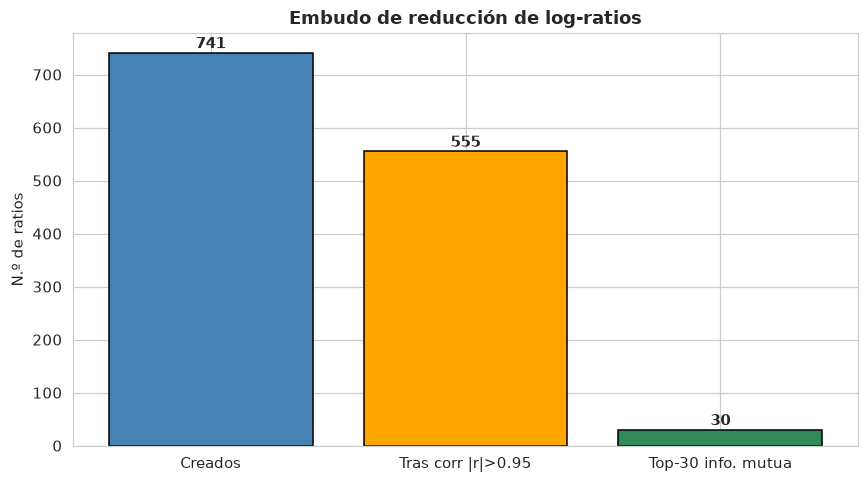

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
b = ax.bar(resumen_fe['Etapa'], resumen_fe['N_ratios'],
           color=['steelblue', 'orange', 'seagreen'], edgecolor='black')
for r in b:
    ax.text(r.get_x()+r.get_width()/2, r.get_height()+2, f'{int(r.get_height())}',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('N.º de ratios'); ax.set_title('Embudo de reducción de log-ratios', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/fe_reduccion_ratios.png', bbox_inches='tight'); plt.show()

## Clustering sobre elementos no económicos

Se generan features de clustering no supervisado (KMeans, GMM, DBSCAN) sobre los elementos no económicos, en dos espacios: valores originales (RAW) y log-transformados (LOG). Cada algoritmo produce features distintas:

- **KMeans:** etiqueta de cluster + distancia al centroide más cercano (señal de borde de dominio).
- **GMM:** etiqueta + probabilidad máxima de pertenencia (confianza de asignación).
- **DBSCAN:** indicador de outlier geoquímico (muestra sin dominio claro).

Los hiperparámetros de cada algoritmo se eligen por criterios internos no supervisados (silhouette para KMeans, BIC para GMM, percentil 90 de k-distancias para DBSCAN), ajustados exclusivamente sobre el conjunto de entrenamiento.

In [13]:
def features_cluster(Xtr_esp, Xte_esp, etiqueta):
    '''Genera 5 features de cluster (KMeans+GMM+DBSCAN) en el espacio dado.'''
    sc = StandardScaler().fit(Xtr_esp)
    Ztr, Zte = sc.transform(Xtr_esp), sc.transform(Xte_esp)

    # KMeans: k por silhouette
    sils = [silhouette_score(Ztr, KMeans(n_clusters=k, random_state=SEED, n_init=10).fit_predict(Ztr))
            for k in range(2, 11)]
    k_km = int(np.argmax(sils)) + 2
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Ztr)

    # GMM: k por BIC
    bics = [GaussianMixture(n_components=k, random_state=SEED).fit(Ztr).bic(Ztr) for k in range(2, 11)]
    k_gmm = int(np.argmin(bics)) + 2
    gm = GaussianMixture(n_components=k_gmm, random_state=SEED).fit(Ztr)

    # DBSCAN: eps por percentil 90 de k-distancias
    nn = NearestNeighbors(n_neighbors=10).fit(Ztr)
    kdist = np.sort(nn.kneighbors(Ztr)[0][:, -1])
    eps = float(np.percentile(kdist, 90))
    db_tr = DBSCAN(eps=eps, min_samples=10).fit_predict(Ztr)
    db_te = DBSCAN(eps=eps, min_samples=10).fit_predict(Zte)

    def dist_centroides(Z):
        return np.min(np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=1)

    ftr = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.labels_,
        f'kmeans_dist_{etiqueta}': dist_centroides(Ztr),
        f'gmm_label_{etiqueta}': gm.predict(Ztr),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Ztr).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_tr == -1).astype(int),
    }, index=Xtr_esp.index)
    fte = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Zte),
        f'kmeans_dist_{etiqueta}': dist_centroides(Zte),
        f'gmm_label_{etiqueta}': gm.predict(Zte),
        f'gmm_prob_max_{etiqueta}': gm.predict_proba(Zte).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_te == -1).astype(int),
    }, index=Xte_esp.index)
    info = {'espacio': etiqueta, 'k_kmeans': k_km, 'k_gmm': k_gmm,
            'eps_dbscan': round(eps, 3), 'n_outliers_train': int((db_tr == -1).sum())}
    curvas = {'sils': sils, 'bics': bics, 'kdist': kdist}
    modelos_cl = {'kmeans': km, 'gmm': gm, 'scaler': sc, 'eps': eps}
    return ftr, fte, info, curvas, modelos_cl

# Espacio RAW y LOG sobre los no económicos
Xtr_raw = X_train[NO_ECON].copy()
Xte_raw = X_test[NO_ECON].copy()
Xtr_log = np.log1p(X_train[NO_ECON].clip(lower=0))
Xte_log = np.log1p(X_test[NO_ECON].clip(lower=0))

cl_raw_tr, cl_raw_te, info_raw, curvas_raw, modelos_cl_raw = features_cluster(Xtr_raw, Xte_raw, 'raw')
cl_log_tr, cl_log_te, info_log, curvas_log, modelos_cl_log = features_cluster(Xtr_log, Xte_log, 'log')

tabla_clust = pd.DataFrame([info_raw, info_log]).set_index('espacio')
tabla_clust.to_csv(f'{DIR_TAB}/clustering_config_raw_log.csv')
print('Configuración de clustering por espacio:')
print(tabla_clust.to_string())

Configuración de clustering por espacio:
         k_kmeans  k_gmm  eps_dbscan  n_outliers_train
espacio                                               
raw             2      5       4.749               105
log             2      4       5.052                86


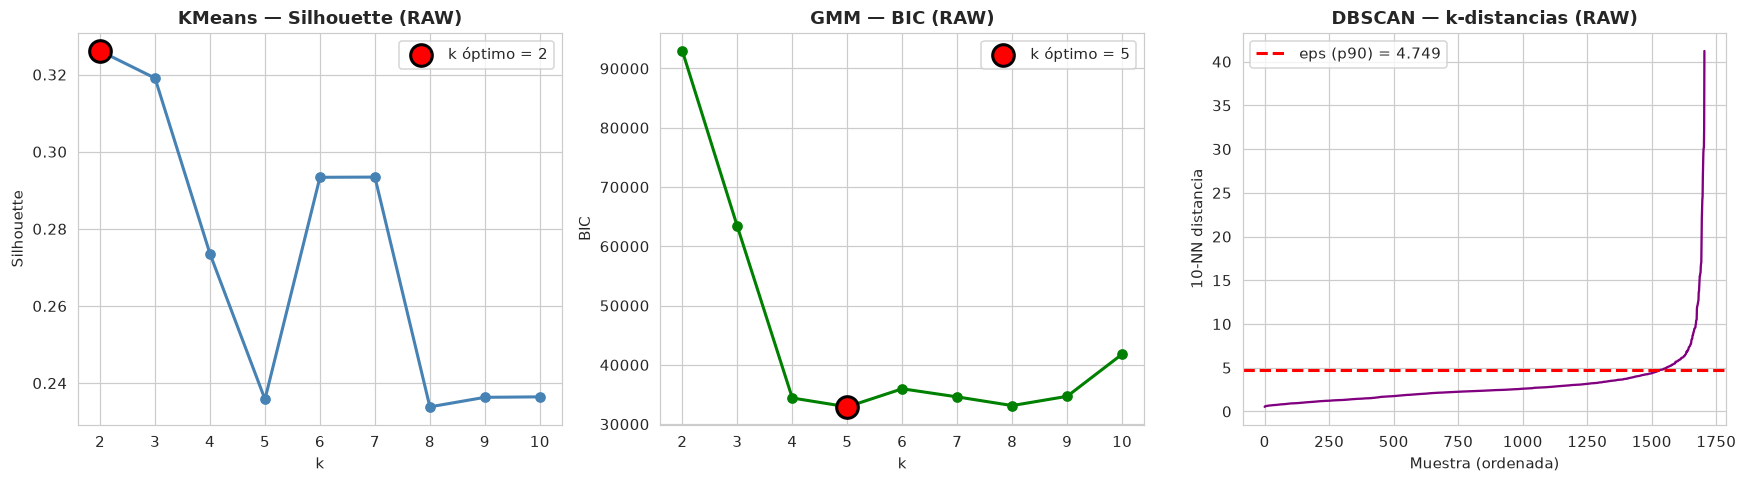

In [14]:
ks = list(range(2, 11))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(ks, curvas_raw['sils'], marker='o', lw=2, color='steelblue')
axes[0].scatter([info_raw['k_kmeans']], [max(curvas_raw['sils'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_raw["k_kmeans"]}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('KMeans — Silhouette (RAW)', fontweight='bold'); axes[0].legend()

axes[1].plot(ks, curvas_raw['bics'], marker='o', lw=2, color='green')
axes[1].scatter([info_raw['k_gmm']], [min(curvas_raw['bics'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_raw["k_gmm"]}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('BIC')
axes[1].set_title('GMM — BIC (RAW)', fontweight='bold'); axes[1].legend()

axes[2].plot(curvas_raw['kdist'], lw=1.5, color='purple')
axes[2].axhline(info_raw['eps_dbscan'], color='red', linestyle='--', lw=2,
                label=f'eps (p90) = {info_raw["eps_dbscan"]:.3f}')
axes[2].set_xlabel('Muestra (ordenada)'); axes[2].set_ylabel('10-NN distancia')
axes[2].set_title('DBSCAN — k-distancias (RAW)', fontweight='bold'); axes[2].legend()
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/clustering_sustento_raw.png', bbox_inches='tight'); plt.show()

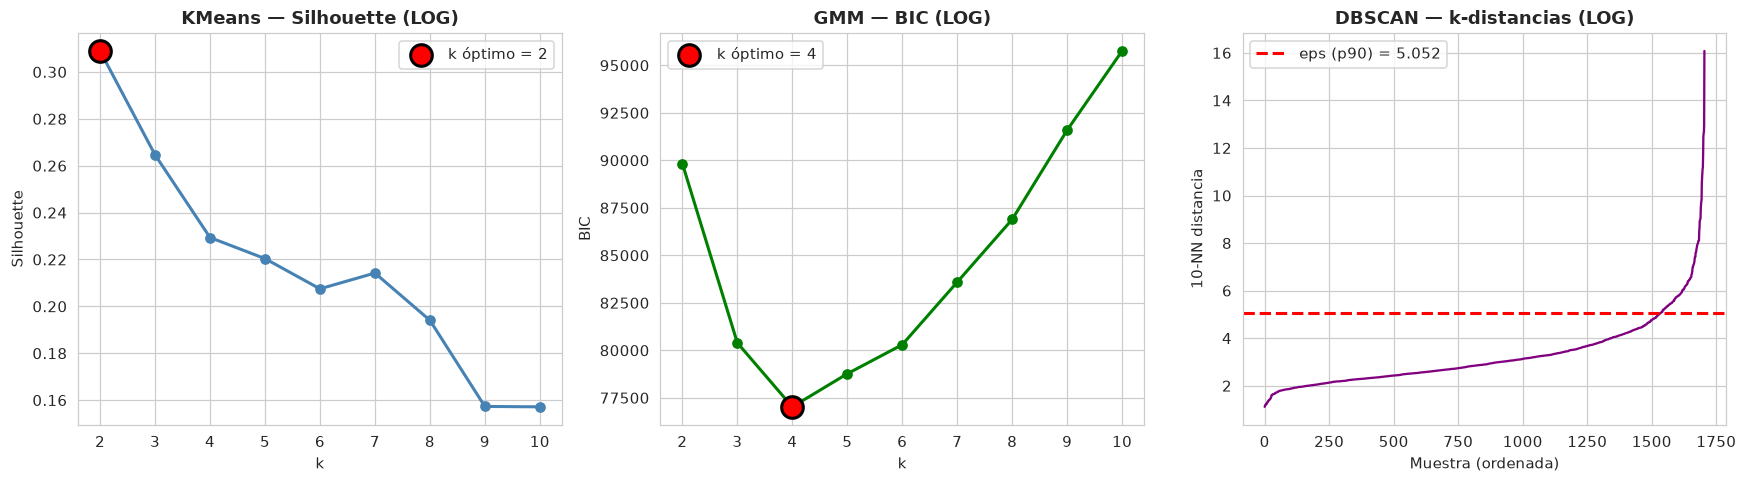

In [15]:
ffig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(ks, curvas_log['sils'], marker='o', lw=2, color='steelblue')
axes[0].scatter([info_log['k_kmeans']], [max(curvas_log['sils'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_log["k_kmeans"]}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('KMeans — Silhouette (LOG)', fontweight='bold'); axes[0].legend()

axes[1].plot(ks, curvas_log['bics'], marker='o', lw=2, color='green')
axes[1].scatter([info_log['k_gmm']], [min(curvas_log['bics'])], s=200, color='red',
                edgecolors='black', linewidths=2, zorder=5, label=f'k óptimo = {info_log["k_gmm"]}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('BIC')
axes[1].set_title('GMM — BIC (LOG)', fontweight='bold'); axes[1].legend()

axes[2].plot(curvas_log['kdist'], lw=1.5, color='purple')
axes[2].axhline(info_log['eps_dbscan'], color='red', linestyle='--', lw=2,
                label=f'eps (p90) = {info_log["eps_dbscan"]:.3f}')
axes[2].set_xlabel('Muestra (ordenada)'); axes[2].set_ylabel('10-NN distancia')
axes[2].set_title('DBSCAN — k-distancias (LOG)', fontweight='bold'); axes[2].legend()
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/clustering_sustento_log.png', bbox_inches='tight'); plt.show()

## Experimentos A/B

Se definen 6 configuraciones de features para evaluar el aporte incremental de cada componente del Feature Engineering:

| Set | Contenido |
|---|---|
| E0 Base | 46 features originales (sin FE) |
| E1 +FE | Features log-transformadas + ratios filtrados |
| E2 +Cluster RAW | Features log-transformadas + 5 features de cluster (RAW) |
| E3 +FE+Cluster RAW | Features log-transformadas + ratios + cluster RAW |
| E4 +Cluster LOG | Features log-transformadas + 5 features de cluster (LOG) |
| E5 +FE+Cluster LOG | Features log-transformadas + ratios + cluster LOG |

Cada modelo se evalúa con el balanceo que le resultó óptimo en el Sprint 1.

In [16]:
# Definición de los 6 sets
E1_tr = pd.concat([X_train_logbase, R_train_filt], axis=1)
E1_te = pd.concat([X_test_logbase,  R_test_filt],  axis=1)
E2_tr = pd.concat([X_train_logbase, cl_raw_tr], axis=1)
E2_te = pd.concat([X_test_logbase,  cl_raw_te], axis=1)
E3_tr = pd.concat([X_train_logbase, R_train_filt, cl_raw_tr], axis=1)
E3_te = pd.concat([X_test_logbase,  R_test_filt,  cl_raw_te], axis=1)
E4_tr = pd.concat([X_train_logbase, cl_log_tr], axis=1)
E4_te = pd.concat([X_test_logbase,  cl_log_te], axis=1)
E5_tr = pd.concat([X_train_logbase, R_train_filt, cl_log_tr], axis=1)
E5_te = pd.concat([X_test_logbase,  R_test_filt,  cl_log_te], axis=1)

sets = {
    'E0 Base':              (X_train, X_test),
    'E1 +FE':               (E1_tr, E1_te),
    'E2 +Cluster RAW':      (E2_tr, E2_te),
    'E3 +FE+Cluster RAW':   (E3_tr, E3_te),
    'E4 +Cluster LOG':      (E4_tr, E4_te),
    'E5 +FE+Cluster LOG':   (E5_tr, E5_te),
}
for nombre, (Xtr_, _) in sets.items():
    print(f'{nombre:24s}: {Xtr_.shape[1]} features')

E0 Base                 : 46 features
E1 +FE                  : 76 features
E2 +Cluster RAW         : 51 features
E3 +FE+Cluster RAW      : 81 features
E4 +Cluster LOG         : 51 features
E5 +FE+Cluster LOG      : 81 features


In [17]:
print('\nEvaluando 6 experimentos × 11 modelos por F1_CV ...')
t0 = time.time()
f1_ab = pd.DataFrame(index=list(sets.keys()), columns=MODELOS, dtype=float)
for exp, (Xtr_, _) in sets.items():
    for mod in MODELOS:
        mu, _ = f1_cv(mod, Xtr_, y_train, balanceo=BAL_POR_MOD[mod])
        f1_ab.loc[exp, mod] = mu
    print(f'  {exp} completado')
print(f'Terminado en {time.time()-t0:.0f}s')
f1_ab = f1_ab.astype(float).round(4)
f1_ab.to_csv(f'{DIR_TAB}/experimentos_f1_cv.csv')

print('\nExperimentos A/B — F1_CV (media) · MÉTRICA PRIMARIA')
f1_ab.style.apply(resaltar_maximo, axis=0).format('{:.4f}')


Evaluando 6 experimentos × 11 modelos por F1_CV ...
  E0 Base completado
  E1 +FE completado
  E2 +Cluster RAW completado
  E3 +FE+Cluster RAW completado
  E4 +Cluster LOG completado
  E5 +FE+Cluster LOG completado
Terminado en 263s

Experimentos A/B — F1_CV (media) · MÉTRICA PRIMARIA


,KNN,Reg. Logística,SVM (RBF),MLP,Árbol de Decisión,Random Forest,ExtraTrees,HistGradientBoosting,XGBoost,LightGBM,CatBoost
E0 Base,0.4876,0.5493,0.4500,0.6436,0.5701,0.6831,0.6498,0.7226,0.7201,0.7245,0.7277
E1 +FE,0.5803,0.6612,0.6433,0.6757,0.5633,0.6847,0.6772,0.7186,0.6939,0.7124,0.7002
E2 +Cluster RAW,0.5638,0.6566,0.6499,0.7052,0.5505,0.6786,0.6957,0.7307,0.7177,0.7259,0.7040
E3 +FE+Cluster RAW,0.5729,0.6576,0.6435,0.6872,0.5325,0.6779,0.7004,0.7151,0.6927,0.7136,0.6944
E4 +Cluster LOG,0.5363,0.6454,0.6499,0.6715,0.5248,0.6633,0.6914,0.7179,0.7032,0.7056,0.6927
E5 +FE+Cluster LOG,0.5478,0.6607,0.6481,0.6732,0.5542,0.6633,0.6879,0.6905,0.6835,0.7136,0.7075


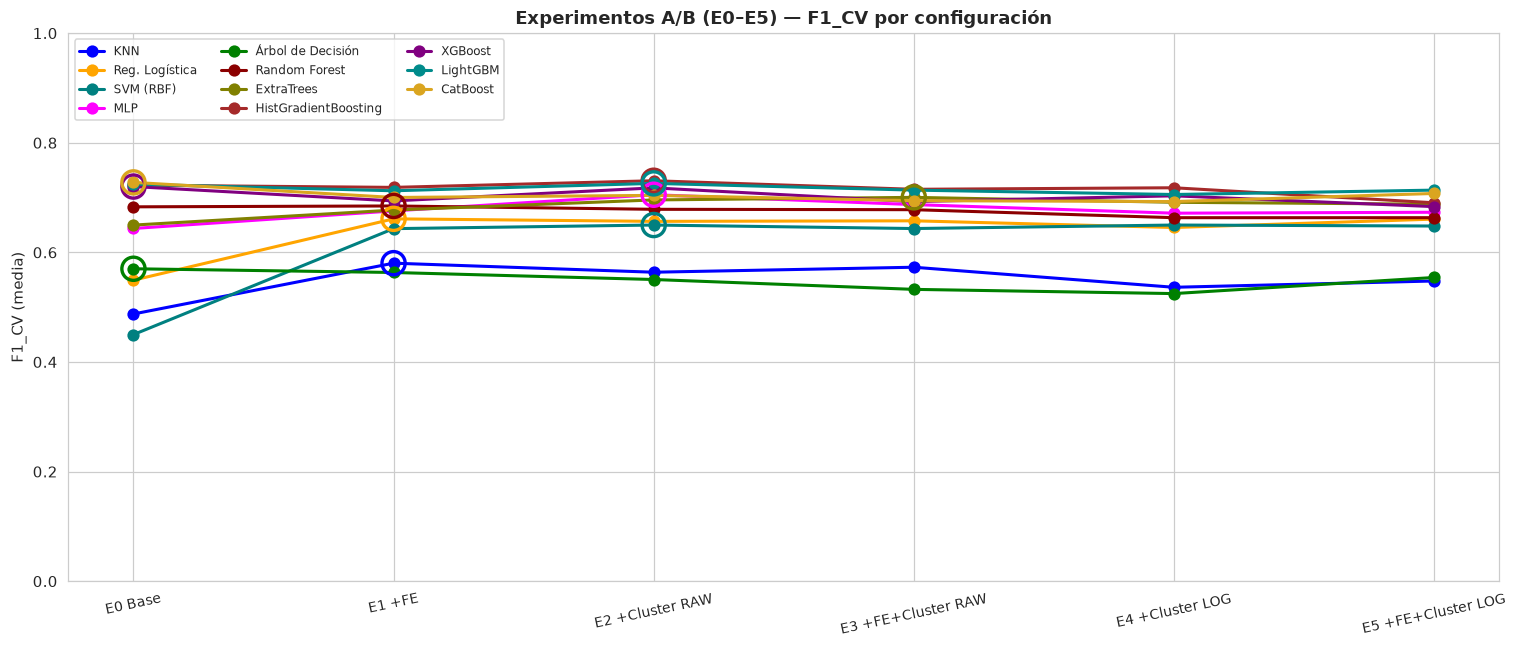

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(f1_ab.index))
for mod in MODELOS:
    ax.plot(x, f1_ab[mod].values, marker='o', lw=2, markersize=7, color=MODEL_COLORS[mod], label=mod)
    xi = int(np.argmax(f1_ab[mod].values))
    ax.scatter([xi], [f1_ab[mod].values[xi]], s=230, facecolors='none',
               edgecolors=MODEL_COLORS[mod], linewidths=2.2, zorder=5)
ax.set_xticks(x); ax.set_xticklabels(list(f1_ab.index), fontsize=9, rotation=12)
ax.set_ylabel('F1_CV (media)'); ax.set_ylim(0, 1)
ax.set_title('Experimentos A/B (E0–E5) — F1_CV por configuración', fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/experimentos_f1_cv_comparacion.png', bbox_inches='tight'); plt.show()

In [19]:
mejor_set_mod = {mod: f1_ab[mod].idxmax() for mod in MODELOS}
resumen_ab = pd.DataFrame({
    'Mejor set':      [mejor_set_mod[m] for m in MODELOS],
    'F1_CV (mejor)':  [round(f1_ab[m].max(), 4) for m in MODELOS],
    'F1_CV (E0)':     [round(f1_ab.loc['E0 Base', m], 4) for m in MODELOS],
}, index=MODELOS)
resumen_ab['Δ F1_CV'] = (resumen_ab['F1_CV (mejor)'] - resumen_ab['F1_CV (E0)']).round(4)
resumen_ab.to_csv(f'{DIR_TAB}/experimentos_mejor_set.csv')
print('Mejor set por modelo (por F1_CV):')
resumen_ab

Mejor set por modelo (por F1_CV):


,Mejor set,F1_CV (mejor),F1_CV (E0),Δ F1_CV
KNN,E1 +FE,0.5803,0.4876,0.0927
Reg. Logística,E1 +FE,0.6612,0.5493,0.1119
SVM (RBF),E2 +Cluster RAW,0.6499,0.4500,0.1999
MLP,E2 +Cluster RAW,0.7052,0.6436,0.0616
Árbol de Decisión,E0 Base,0.5701,0.5701,0.0000
Random Forest,E1 +FE,0.6847,0.6831,0.0016
ExtraTrees,E3 +FE+Cluster RAW,0.7004,0.6498,0.0506
HistGradientBoosting,E2 +Cluster RAW,0.7307,0.7226,0.0081
XGBoost,E0 Base,0.7201,0.7201,0.0000
LightGBM,E2 +Cluster RAW,0.7259,0.7245,0.0014


## Optimización de hiperparámetros con Optuna

Se realiza una búsqueda bayesiana (TPE) de hiperparámetros para cada uno de los 11 modelos, usando su mejor set de features y su mejor balanceo. El objetivo es maximizar F1\_CV 5-fold.

**Presupuesto de trials:** se asignan **100 trials** a los 4 modelos con mayor F1\_CV en el screening de experimentos (asignación de presupuesto proporcional al potencial), y **50 trials** a los 7 restantes. Esto optimiza el tiempo de cómputo sin sacrificar la exhaustividad en los modelos más prometedores.

`TPESampler(seed=SEED)` garantiza la reproducibilidad de la búsqueda.

In [20]:
def espacio_optuna(mod, trial):
    '''Define el espacio de búsqueda de hiperparámetros por modelo.'''
    if mod == 'KNN':
        return {'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)}
    if mod == 'Reg. Logística':
        return {'C': trial.suggest_float('C', 0.01, 10, log=True),
                'max_iter': trial.suggest_categorical('max_iter', [500, 1000])}
    if mod == 'SVM (RBF)':
        return {'C': trial.suggest_float('C', 0.1, 10, log=True),
                'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])}
    if mod == 'MLP':
        return {'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (100, 50)]),
                'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
                'max_iter': trial.suggest_categorical('max_iter', [300, 500])}
    if mod == 'Árbol de Decisión':
        return {'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20)}
    if mod == 'Random Forest':
        return {'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 30),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)}
    if mod == 'ExtraTrees':
        return {'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 30),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)}
    if mod == 'HistGradientBoosting':
        return {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'max_iter': trial.suggest_int('max_iter', 50, 200),
                'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 50),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
                'l2_regularization': trial.suggest_float('l2_regularization', 0, 2)}
    if mod == 'XGBoost':
        return {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0)}
    if mod == 'LightGBM':
        return {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 50, 200),
                'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 50)}
    if mod == 'CatBoost':
        return {'iterations': trial.suggest_int('iterations', 50, 200),
                'depth': trial.suggest_int('depth', 4, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True)}
    raise ValueError(mod)

def crear_clf_optuna(mod, params):
    '''Instancia un clasificador con hiperparámetros dados por Optuna.'''
    if mod == 'KNN':                  return __import__('sklearn.neighbors', fromlist=['KNeighborsClassifier']).KNeighborsClassifier(**params)
    if mod == 'Reg. Logística':       return __import__('sklearn.linear_model', fromlist=['LogisticRegression']).LogisticRegression(**params, random_state=SEED)
    if mod == 'SVM (RBF)':            return __import__('sklearn.svm', fromlist=['SVC']).SVC(kernel='rbf', probability=True, class_weight='balanced', **params, random_state=SEED)
    if mod == 'MLP':                  return __import__('sklearn.neural_network', fromlist=['MLPClassifier']).MLPClassifier(**params, random_state=SEED)
    if mod == 'Árbol de Decisión':    return __import__('sklearn.tree', fromlist=['DecisionTreeClassifier']).DecisionTreeClassifier(**params, random_state=SEED)
    if mod == 'Random Forest':        return __import__('sklearn.ensemble', fromlist=['RandomForestClassifier']).RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    if mod == 'ExtraTrees':           return __import__('sklearn.ensemble', fromlist=['ExtraTreesClassifier']).ExtraTreesClassifier(**params, random_state=SEED, n_jobs=-1)
    if mod == 'HistGradientBoosting': return __import__('sklearn.ensemble', fromlist=['HistGradientBoostingClassifier']).HistGradientBoostingClassifier(**params, random_state=SEED)
    if mod == 'XGBoost':              return xgb.XGBClassifier(**params, random_state=SEED, eval_metric='logloss', tree_method='hist', n_jobs=-1)
    if mod == 'LightGBM':             return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)
    if mod == 'CatBoost':             return CatBoostClassifier(**params, random_seed=SEED, verbose=0, allow_writing_files=False)
    raise ValueError(mod)

def pipeline_optuna(mod, params, balanceo):
    '''Pipeline con hiperparámetros de Optuna.'''
    pasos = [('sc', StandardScaler())]
    bal = crear_balanceador(balanceo)
    if bal is not None:
        pasos.append(('bal', bal))
    pasos.append(('clf', crear_clf_optuna(mod, params)))
    return ImbPipeline(pasos)

def make_objective(mod, Xtr_m, bal_m):
    def objective(trial):
        params = espacio_optuna(mod, trial)
        pipe = pipeline_optuna(mod, params, bal_m)
        sc = cross_val_score(pipe, Xtr_m, y_train, cv=CV5, scoring='f1', n_jobs=-1)
        trial.set_user_attr('std', float(sc.std()))
        return sc.mean()
    return objective

# ── Asignar trials: 100 a los top-4 del screening, 50 al resto ──
f1_screening = {mod: f1_ab[mod].max() for mod in MODELOS}
ranking_screening = sorted(f1_screening, key=f1_screening.get, reverse=True)
TOP_4 = ranking_screening[:4]
trials_por_modelo = {mod: (100 if mod in TOP_4 else 50) for mod in MODELOS}
print(f'Top-4 del screening (100 trials): {TOP_4}')
print(f'Resto (50 trials): {ranking_screening[4:]}')

studies, optuna_res = {}, {}
print(f'\nOptuna: optimizando los {len(MODELOS)} modelos ...\n')
t_glob = time.time()
for mod in MODELOS:
    set_m = mejor_set_mod[mod]
    Xtr_m, _ = sets[set_m]
    bal_m = BAL_POR_MOD[mod]
    n_trials = trials_por_modelo[mod]
    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(make_objective(mod, Xtr_m, bal_m), n_trials=n_trials, n_jobs=1, show_progress_bar=False)
    studies[mod] = study
    f1_def, std_def = f1_cv(mod, Xtr_m, y_train, balanceo=bal_m)
    std_opt = float(study.best_trial.user_attrs.get('std', np.nan))
    optuna_res[mod] = {'set': set_m, 'bal': bal_m, 'n_trials': n_trials,
                       'f1_default': float(f1_def), 'std_default': float(std_def),
                       'f1_optuna': float(study.best_value), 'std_optuna': std_opt,
                       'params': study.best_params}
    print(f'  {mod:22s} [{n_trials:3d}t] set={set_m:20s} F1_def={f1_def:.4f}±{std_def:.4f} → '
          f'F1_opt={study.best_value:.4f}±{std_opt:.4f} (Δ={study.best_value-f1_def:+.4f}, {time.time()-t0:.0f}s)')
print(f'\nOptuna total: {time.time()-t_glob:.0f}s')

Top-4 del screening (100 trials): ['HistGradientBoosting', 'CatBoost', 'LightGBM', 'XGBoost']
Resto (50 trials): ['MLP', 'ExtraTrees', 'Random Forest', 'Reg. Logística', 'SVM (RBF)', 'KNN', 'Árbol de Decisión']

Optuna: optimizando los 11 modelos ...

  KNN                    [ 50t] set=E1 +FE               F1_def=0.5803±0.0402 → F1_opt=0.6174±0.0530 (Δ=+0.0371, 6s)
  Reg. Logística         [ 50t] set=E1 +FE               F1_def=0.6612±0.0431 → F1_opt=0.6721±0.0248 (Δ=+0.0110, 9s)
  SVM (RBF)              [ 50t] set=E2 +Cluster RAW      F1_def=0.6499±0.0434 → F1_opt=0.6728±0.0593 (Δ=+0.0229, 118s)
  MLP                    [ 50t] set=E2 +Cluster RAW      F1_def=0.7052±0.0577 → F1_opt=0.7069±0.0572 (Δ=+0.0017, 413s)
  Árbol de Decisión      [ 50t] set=E0 Base              F1_def=0.5701±0.0302 → F1_opt=0.5853±0.0183 (Δ=+0.0152, 18s)
  Random Forest          [ 50t] set=E1 +FE               F1_def=0.6847±0.0527 → F1_opt=0.6986±0.0542 (Δ=+0.0139, 268s)
  ExtraTrees             [ 50t] set=E3 

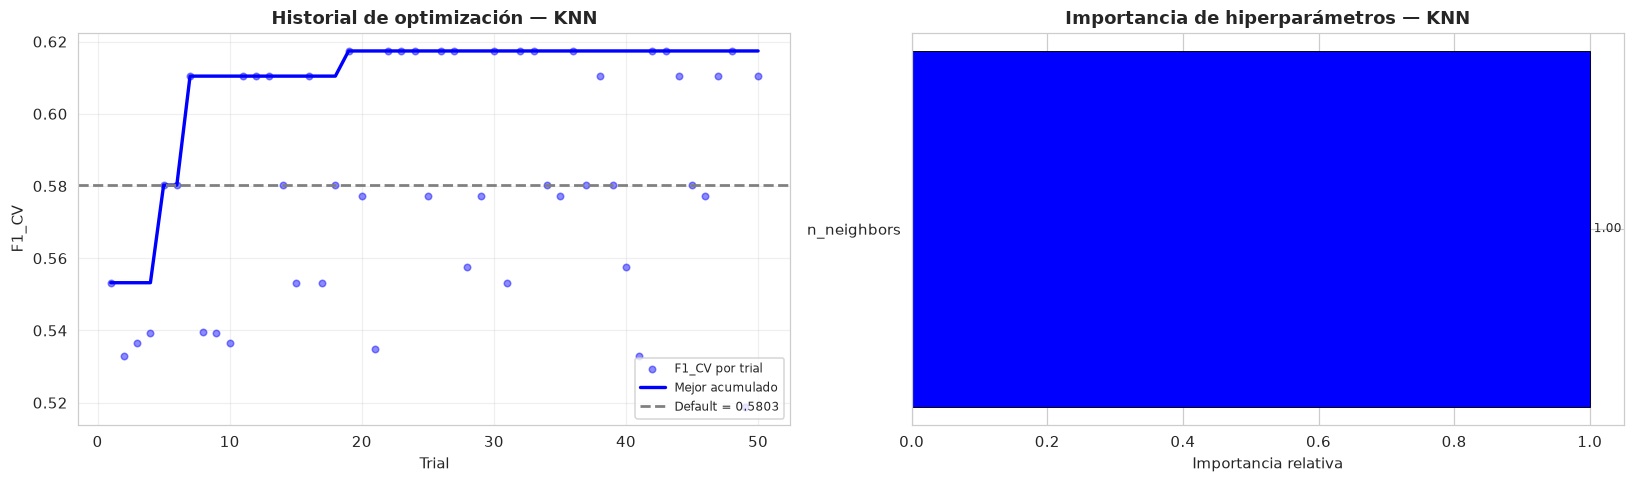

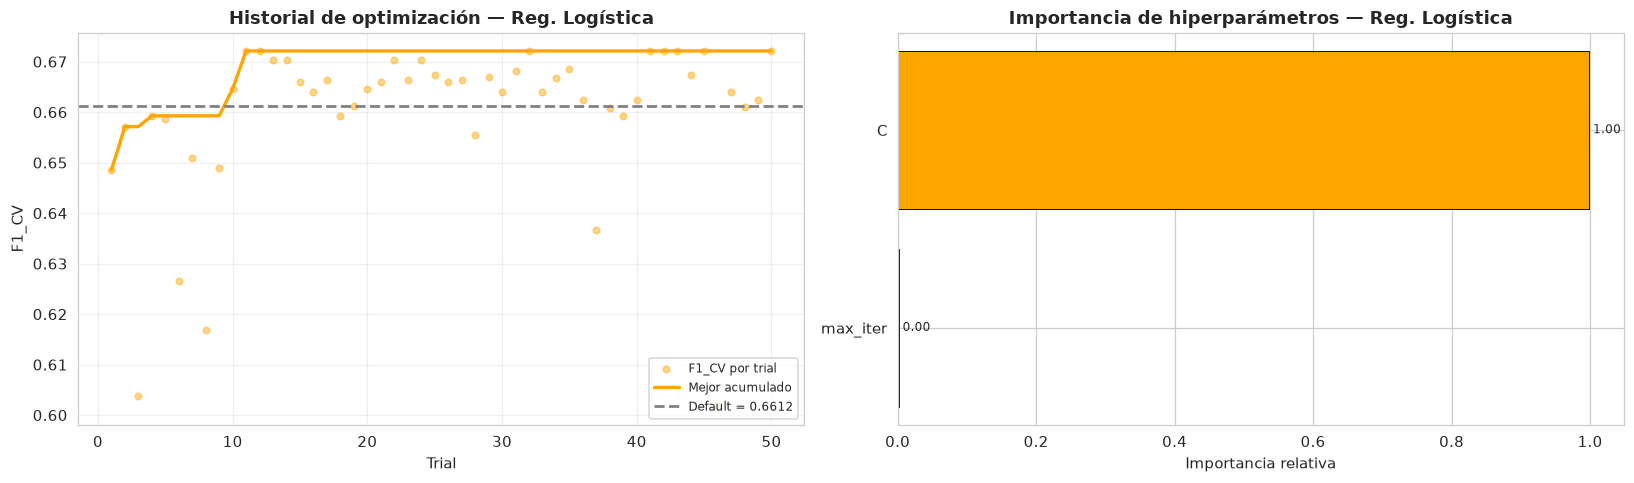

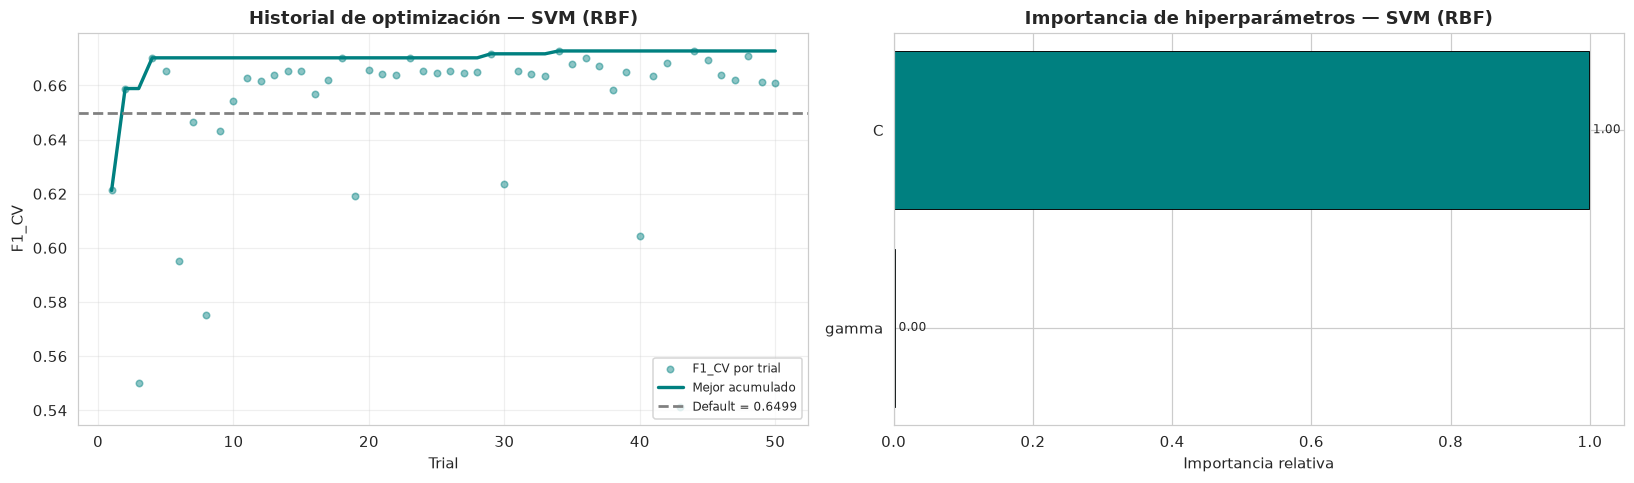

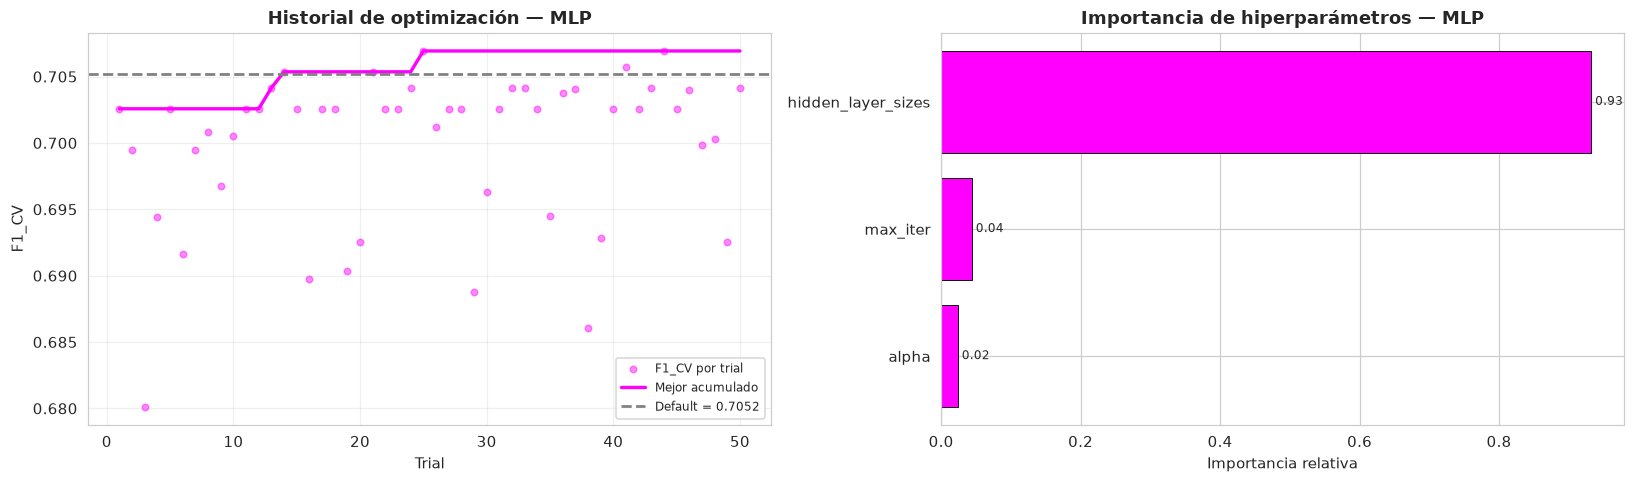

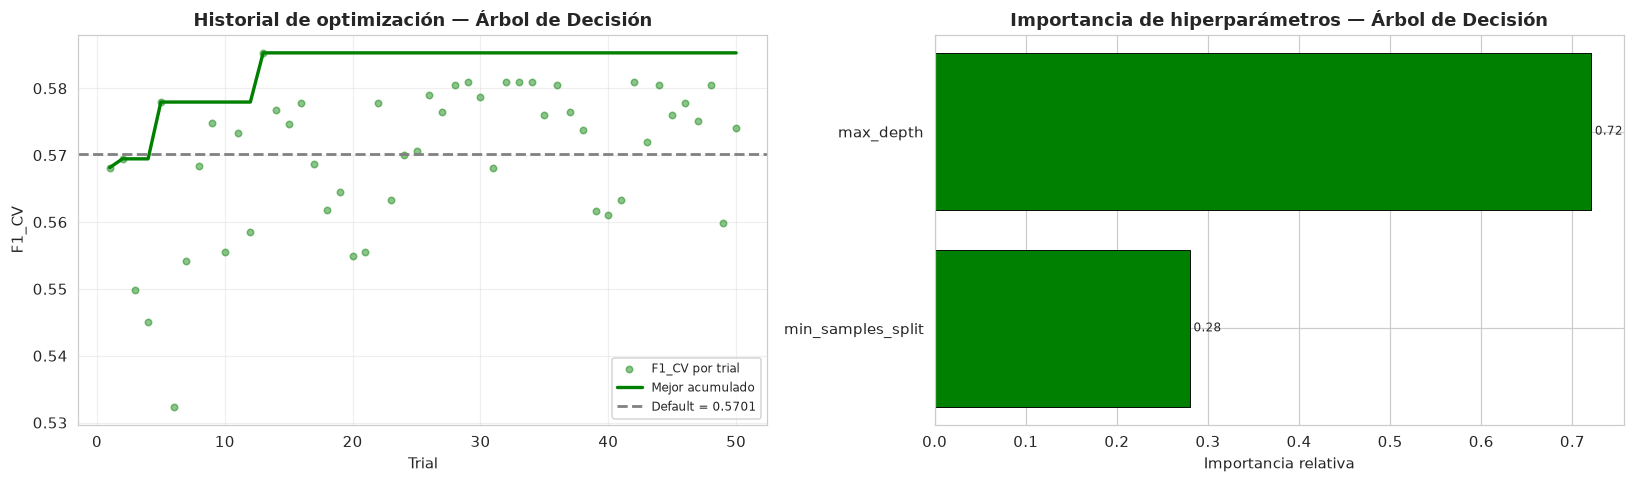

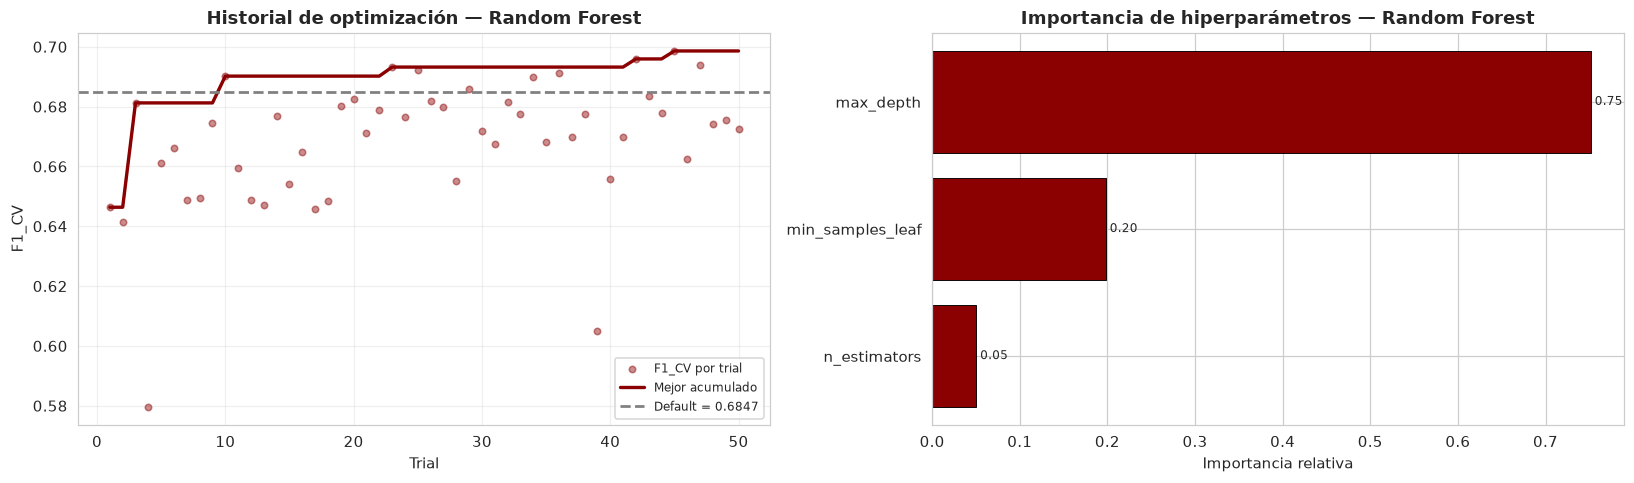

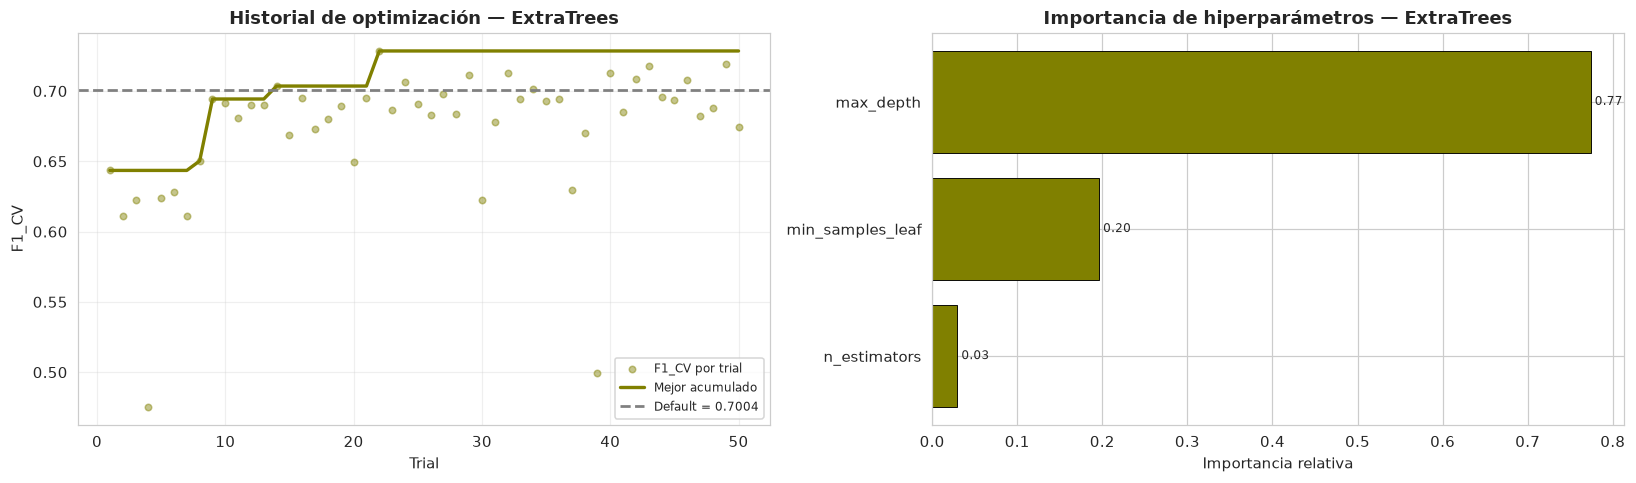

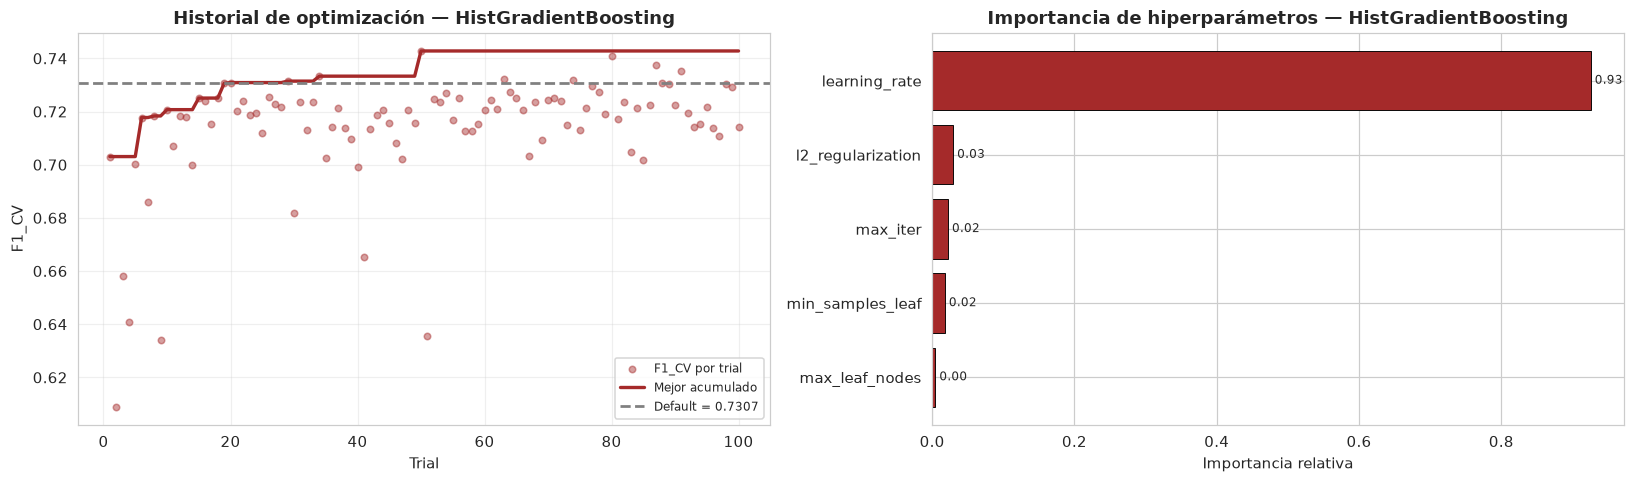

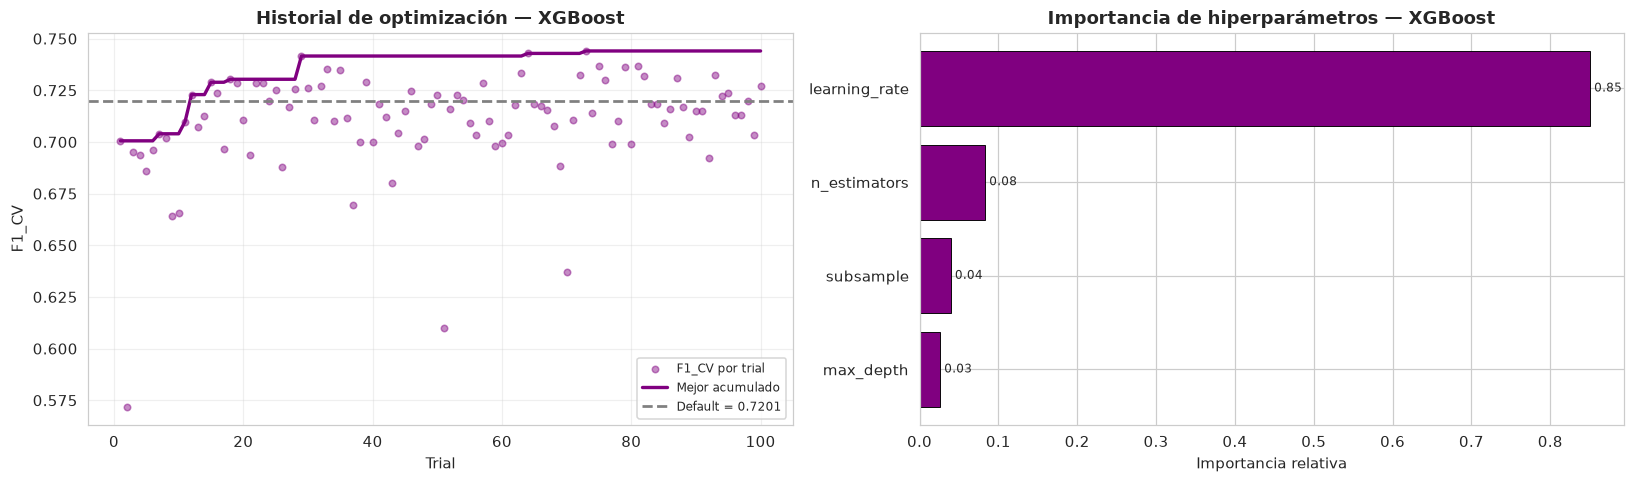

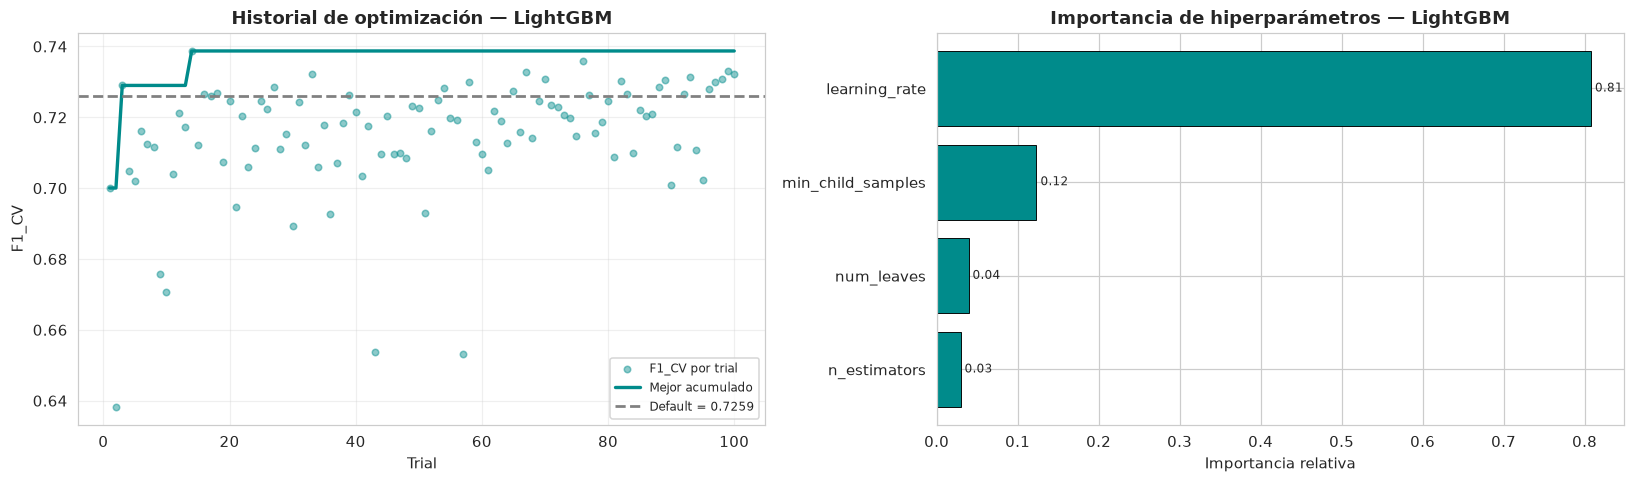

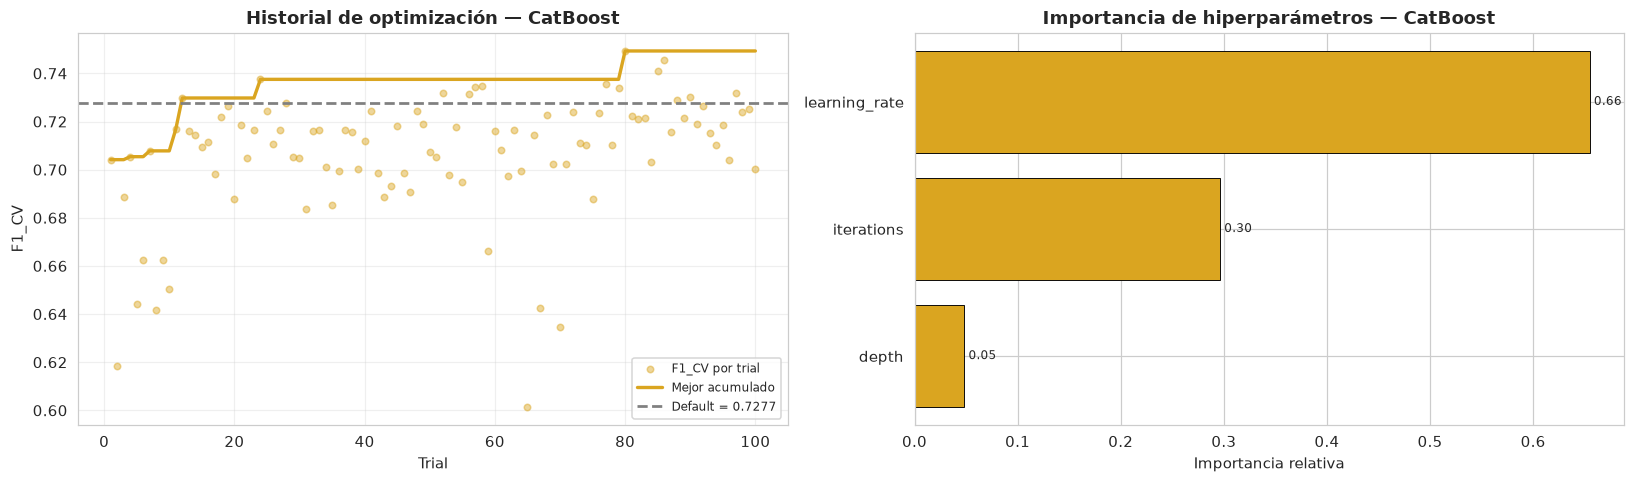

In [21]:
def slug(txt):
    return re.sub(r'[^a-z0-9]+', '_', txt.lower()).strip('_')

def plot_optuna_modelo(study, mod, f1_def):
    '''Historial de optimización e importancia de hiperparámetros.'''
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    color = MODEL_COLORS[mod]
    vals = [t.value for t in study.trials if t.value is not None]
    best_run = np.maximum.accumulate(vals)
    xs = range(1, len(vals) + 1)
    axes[0].scatter(list(xs), vals, s=18, alpha=0.45, color=color, label='F1_CV por trial')
    axes[0].plot(list(xs), best_run, lw=2.2, color=color, label='Mejor acumulado')
    axes[0].axhline(f1_def, ls='--', lw=1.8, color='gray', label=f'Default = {f1_def:.4f}')
    axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1_CV')
    axes[0].set_title(f'Historial de optimización — {mod}', fontweight='bold')
    axes[0].legend(fontsize=8, loc='lower right'); axes[0].grid(True, alpha=0.3)
    try:
        imp = optuna.importance.get_param_importances(study)
        nombres = list(imp.keys())[::-1]; valores = [imp[k] for k in nombres]
        axes[1].barh(nombres, valores, color=color, edgecolor='black', linewidth=0.6)
        for i, v in enumerate(valores):
            axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=8)
        axes[1].set_xlabel('Importancia relativa')
    except Exception as e:
        axes[1].text(0.5, 0.5, f'Importancia no disponible\n({e})', ha='center', va='center')
        axes[1].axis('off')
    axes[1].set_title(f'Importancia de hiperparámetros — {mod}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{DIR_FIG}/optuna_{slug(mod)}.png', bbox_inches='tight')
    plt.show()

for mod in MODELOS:
    plot_optuna_modelo(studies[mod], mod, optuna_res[mod]['f1_default'])

## Comparación de resultados

In [22]:
tabla_opt = pd.DataFrame({
    'Mejor set':        [optuna_res[m]['set'] for m in MODELOS],
    'Balanceo':         [optuna_res[m]['bal'] for m in MODELOS],
    'Trials':           [optuna_res[m]['n_trials'] for m in MODELOS],
    'F1_CV (default)':  [round(optuna_res[m]['f1_default'], 4) for m in MODELOS],
    '± std (def)':      [round(optuna_res[m]['std_default'], 4) for m in MODELOS],
    'F1_CV (Optuna)':   [round(optuna_res[m]['f1_optuna'], 4) for m in MODELOS],
    '± std (opt)':      [round(optuna_res[m]['std_optuna'], 4) for m in MODELOS],
}, index=MODELOS)
tabla_opt['Δ Optuna'] = (tabla_opt['F1_CV (Optuna)'] - tabla_opt['F1_CV (default)']).round(4)
usa_opt = tabla_opt['F1_CV (Optuna)'] >= tabla_opt['F1_CV (default)']
tabla_opt['F1_CV (mejor)'] = np.where(usa_opt, tabla_opt['F1_CV (Optuna)'], tabla_opt['F1_CV (default)']).round(4)
tabla_opt['± std (mejor)'] = np.where(usa_opt, tabla_opt['± std (opt)'], tabla_opt['± std (def)']).round(4)
tabla_opt = tabla_opt.sort_values('F1_CV (mejor)', ascending=False)
tabla_opt.to_csv(f'{DIR_TAB}/optuna_comparativa_modelos.csv')
print('Comparativa Optuna — 11 modelos (decisión por F1_CV):')
print(tabla_opt.to_string())

Comparativa Optuna — 11 modelos (decisión por F1_CV):
                               Mejor set           Balanceo  Trials  F1_CV (default)  ± std (def)  F1_CV (Optuna)  ± std (opt)  Δ Optuna  F1_CV (mejor)  ± std (mejor)
CatBoost                         E0 Base  RandomOverSampler     100           0.7277       0.0464          0.7493       0.0457    0.0216         0.7493         0.0457
XGBoost                          E0 Base  RandomOverSampler     100           0.7201       0.0286          0.7440       0.0487    0.0239         0.7440         0.0487
HistGradientBoosting     E2 +Cluster RAW  RandomOverSampler     100           0.7307       0.0372          0.7428       0.0402    0.0121         0.7428         0.0402
LightGBM                 E2 +Cluster RAW         SMOTETomek     100           0.7259       0.0587          0.7387       0.0347    0.0128         0.7387         0.0347
ExtraTrees            E3 +FE+Cluster RAW              SMOTE      50           0.7004       0.0239          0.72

In [23]:
tabla_opt.style.apply(
    lambda s: ['background-color: coral; color: white; font-weight: bold'
               if s.name == 'F1_CV (mejor)' and v == s.max() else '' for v in s],
    axis=0
).format({'F1_CV (default)': '{:.4f}', '± std (def)': '{:.4f}',
          'F1_CV (Optuna)': '{:.4f}', '± std (opt)': '{:.4f}',
          'Δ Optuna': '{:+.4f}', 'F1_CV (mejor)': '{:.4f}', '± std (mejor)': '{:.4f}'})

,Mejor set,Balanceo,Trials,F1_CV (default),± std (def),F1_CV (Optuna),± std (opt),Δ Optuna,F1_CV (mejor),± std (mejor)
CatBoost,E0 Base,RandomOverSampler,100,0.7277,0.0464,0.7493,0.0457,+0.0216,0.7493,0.0457
XGBoost,E0 Base,RandomOverSampler,100,0.7201,0.0286,0.7440,0.0487,+0.0239,0.7440,0.0487
HistGradientBoosting,E2 +Cluster RAW,RandomOverSampler,100,0.7307,0.0372,0.7428,0.0402,+0.0121,0.7428,0.0402
LightGBM,E2 +Cluster RAW,SMOTETomek,100,0.7259,0.0587,0.7387,0.0347,+0.0128,0.7387,0.0347
ExtraTrees,E3 +FE+Cluster RAW,SMOTE,50,0.7004,0.0239,0.7285,0.0142,+0.0281,0.7285,0.0142
MLP,E2 +Cluster RAW,ADASYN,50,0.7052,0.0577,0.7069,0.0572,+0.0017,0.7069,0.0572
Random Forest,E1 +FE,SMOTE,50,0.6847,0.0527,0.6986,0.0542,+0.0139,0.6986,0.0542
SVM (RBF),E2 +Cluster RAW,SMOTE,50,0.6499,0.0434,0.6728,0.0593,+0.0229,0.6728,0.0593
Reg. Logística,E1 +FE,Sin balanceo,50,0.6612,0.0431,0.6721,0.0248,+0.0109,0.6721,0.0248
KNN,E1 +FE,RandomOverSampler,50,0.5803,0.0402,0.6174,0.0530,+0.0371,0.6174,0.0530


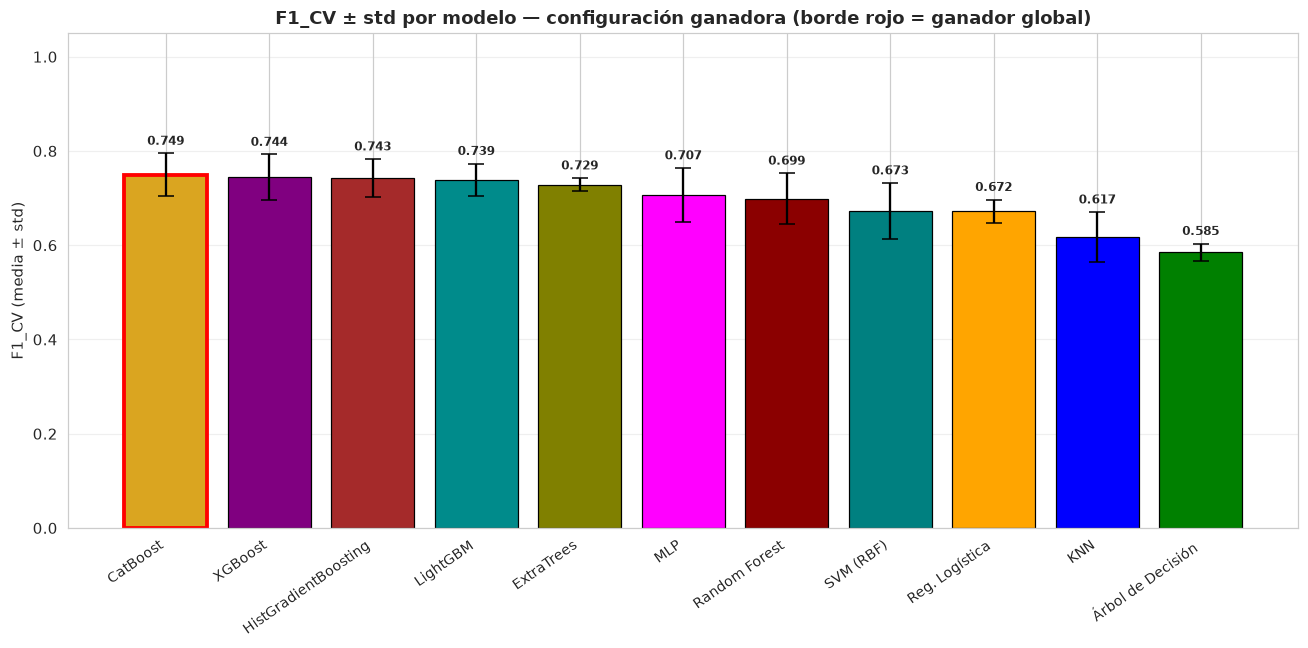

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
orden = tabla_opt.index.tolist()
medias = tabla_opt['F1_CV (mejor)'].values
stds = tabla_opt['± std (mejor)'].values
colores = [MODEL_COLORS[m] for m in orden]
barras = ax.bar(range(len(orden)), medias, yerr=stds, capsize=5,
                color=colores, edgecolor='black', linewidth=0.8,
                error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
idx_win = int(np.argmax(medias))
barras[idx_win].set_edgecolor('red'); barras[idx_win].set_linewidth(2.5)
for i, (mu, sd) in enumerate(zip(medias, stds)):
    ax.text(i, mu + sd + 0.012, f'{mu:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(orden))); ax.set_xticklabels(orden, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1_CV (media ± std)'); ax.set_ylim(0, 1.05)
ax.set_title('F1_CV ± std por modelo — configuración ganadora (borde rojo = ganador global)', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/optuna_f1_cv_std_barras.png', bbox_inches='tight'); plt.show()

## Selección de los top-3 modelos

Se seleccionan los **3 modelos con mayor F1\_CV** (post-Optuna o default, el que sea mayor). Este criterio es objetivo, pre-especificado y no manipulable: evita sesgo de selección y es directamente defendible ("se seleccionaron los 3 modelos de mayor desempeño tras optimización exhaustiva de hiperparámetros").

### Verificación de estabilidad por semillas

Para demostrar que el ranking de los top-3 no es un artefacto de los folds específicos del CV, se repite el F1\_CV con 3 semillas adicionales y se reporta la media ± std global. Esto neutraliza la observación de "sobreajuste al esquema de validación".

In [25]:
# ── Top-3 por F1_CV ──
ranking_final = tabla_opt['F1_CV (mejor)'].sort_values(ascending=False)
TOP_3 = ranking_final.head(3).index.tolist()
print(coral(f'Top-3 seleccionados: {TOP_3}'))
for i, mod in enumerate(TOP_3, 1):
    print(f'  {i}. {mod:22s} F1_CV = {ranking_final[mod]:.4f} ± {tabla_opt.loc[mod, "± std (mejor)"]:.4f}')

# ── Verificación de estabilidad con múltiples semillas ──
SEMILLAS_EXTRA = [123, 456, 789]
print(f'\nVerificación de estabilidad (semillas extra: {SEMILLAS_EXTRA}):')
estabilidad = {}
for mod in TOP_3:
    set_m = optuna_res[mod]['set']
    Xtr_m, _ = sets[set_m]
    bal_m = optuna_res[mod]['bal']
    params_m = optuna_res[mod]['params']
    usa_optuna = optuna_res[mod]['f1_optuna'] >= optuna_res[mod]['f1_default']
    f1s = [ranking_final[mod]]  # F1 con SEED=42
    for s in SEMILLAS_EXTRA:
        cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        if usa_optuna and params_m:
            pipe = pipeline_optuna(mod, params_m, bal_m)
        else:
            pipe = construir_pipeline(mod, bal_m)
        sc = cross_val_score(pipe, Xtr_m, y_train, cv=cv_s, scoring='f1', n_jobs=-1)
        f1s.append(sc.mean())
    estabilidad[mod] = {'f1_semillas': f1s, 'media': np.mean(f1s), 'std': np.std(f1s)}
    print(f'  {mod:22s}: semillas={[round(f,4) for f in f1s]} → media={np.mean(f1s):.4f} ± {np.std(f1s):.4f}')

pd.DataFrame({mod: {'F1_media': round(v['media'], 4), 'F1_std': round(v['std'], 4)}
              for mod, v in estabilidad.items()}).T.to_csv(f'{DIR_TAB}/top3_estabilidad_semillas.csv')

Top-3 seleccionados: ['CatBoost', 'XGBoost', 'HistGradientBoosting']
  1. CatBoost               F1_CV = 0.7493 ± 0.0457
  2. XGBoost                F1_CV = 0.7440 ± 0.0487
  3. HistGradientBoosting   F1_CV = 0.7428 ± 0.0402

Verificación de estabilidad (semillas extra: [123, 456, 789]):
  CatBoost              : semillas=[np.float64(0.7493), np.float64(0.7214), np.float64(0.7053), np.float64(0.6879)] → media=0.7160 ± 0.0226
  XGBoost               : semillas=[np.float64(0.744), np.float64(0.7191), np.float64(0.7086), np.float64(0.7065)] → media=0.7196 ± 0.0149
  HistGradientBoosting  : semillas=[np.float64(0.7428), np.float64(0.7124), np.float64(0.7232), np.float64(0.7019)] → media=0.7201 ± 0.0151


## Evaluación del ganador en hold-out (informativo)

Se evalúa el modelo ganador (top-1) en hold-out una sola vez, con fines informativos. La decisión ya fue tomada por F1\_CV.

In [26]:
mejor_modelo_ab = TOP_3[0]
mejor_set_ab = optuna_res[mejor_modelo_ab]['set']
mejor_bal_ab = optuna_res[mejor_modelo_ab]['bal']
Xtr_ganador, Xte_ganador = sets[mejor_set_ab]

f1_def_g = optuna_res[mejor_modelo_ab]['f1_default']
f1_opt_g = optuna_res[mejor_modelo_ab]['f1_optuna']
if f1_opt_g >= f1_def_g:
    config_final, f1_final, params_final = '+ Optuna', f1_opt_g, optuna_res[mejor_modelo_ab]['params']
else:
    config_final, f1_final, params_final = 'Default', f1_def_g, {}

print(coral(f'GANADOR GLOBAL: {mejor_modelo_ab} con "{mejor_set_ab}"'))
print(f'   Balanceo: {mejor_bal_ab} | Config: {config_final}')
print(coral(f'   F1_CV = {f1_final:.4f}'))
print(f'   Params: {params_final}')

GANADOR GLOBAL: CatBoost con "E0 Base"
   Balanceo: RandomOverSampler | Config: + Optuna
   F1_CV = 0.7493
   Params: {'iterations': 192, 'depth': 5, 'learning_rate': 0.09652506867857727}


In [27]:
if config_final == '+ Optuna':
    pipe_final = pipeline_optuna(mejor_modelo_ab, params_final, mejor_bal_ab)
else:
    pipe_final = construir_pipeline(mejor_modelo_ab, mejor_bal_ab)

pipe_final.fit(Xtr_ganador, y_train)
y_pred_ho = pipe_final.predict(Xte_ganador)
y_sco_ho = scores_pos(pipe_final, Xte_ganador)
metr_ho = metricas_holdout(y_test, y_pred_ho, y_sco_ho)

METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR']
print('Métricas en HOLD-OUT (informativas):')
for m in METRICAS:
    print(f'  {m}: {metr_ho[m]:.4f}')

Métricas en HOLD-OUT (informativas):
  F1: 0.7788
  Accuracy: 0.9415
  Precision: 0.7213
  Recall: 0.8462
  AUC-ROC: 0.9571
  AUC-PR: 0.8387


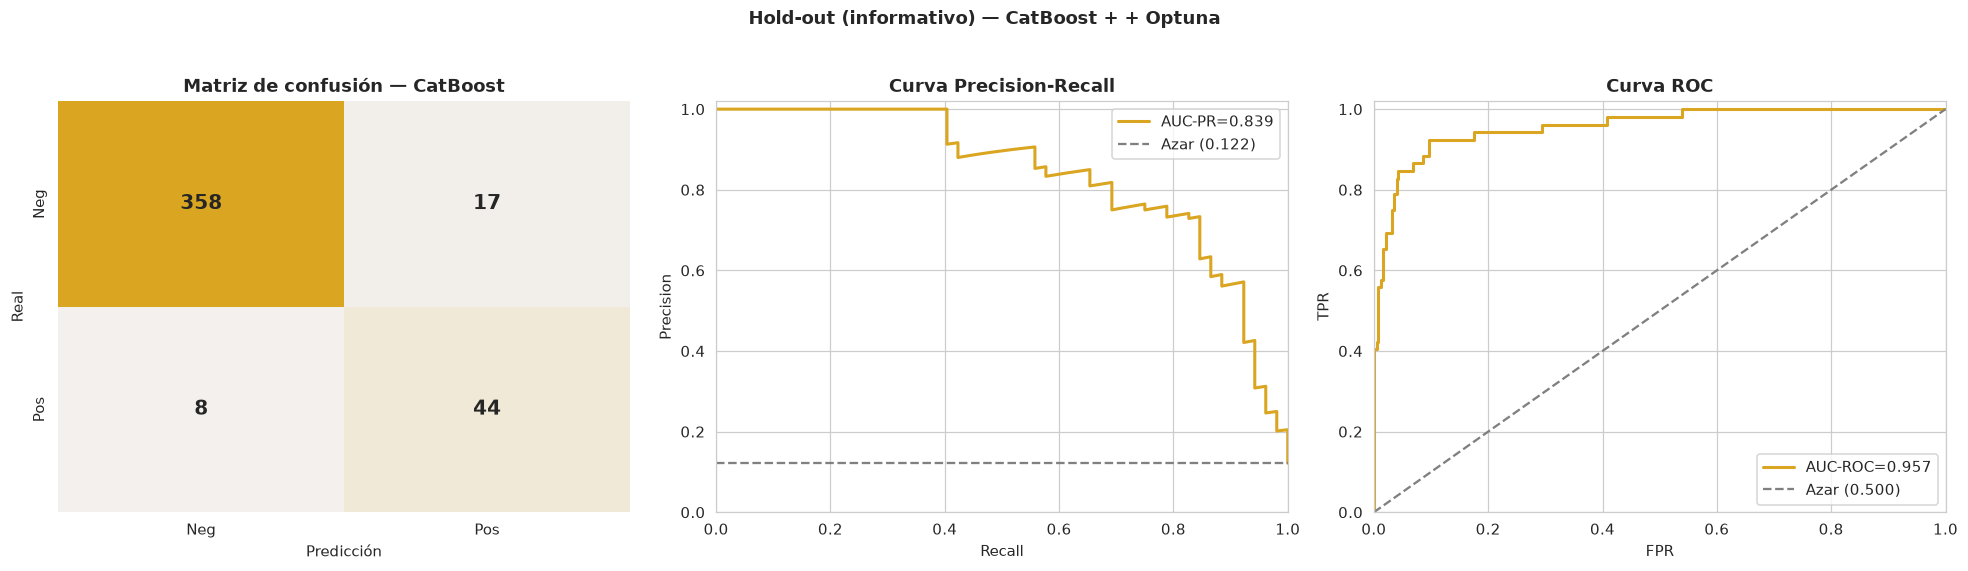

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred_ho)
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(MODEL_COLORS[mejor_modelo_ab], as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title(f'Matriz de confusión — {mejor_modelo_ab}', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

p, r, _ = precision_recall_curve(y_test, y_sco_ho)
axes[1].plot(r, p, color=MODEL_COLORS[mejor_modelo_ab], lw=2, label=f'AUC-PR={metr_ho["AUC-PR"]:.3f}')
axes[1].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva Precision-Recall', fontweight='bold'); axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, y_sco_ho)
axes[2].plot(fpr, tpr, color=MODEL_COLORS[mejor_modelo_ab], lw=2, label=f'AUC-ROC={metr_ho["AUC-ROC"]:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)
axes[2].set_title('Curva ROC', fontweight='bold'); axes[2].legend(loc='lower right')
plt.suptitle(f'Hold-out (informativo) — {mejor_modelo_ab} + {config_final}', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/final_curvas_holdout.png', bbox_inches='tight'); plt.show()

## Persistencia de artefactos

Se guardan los datasets transformados, la lista de features, los modelos optimizados y los modelos de clustering para que el Sprint 3 los cargue directamente sin reconstruir el Feature Engineering.

In [29]:
# ── Guardar datasets transformados (parquet) ──
Xtr_ganador.to_parquet(f'{DIR_DATA}/X_S2_train.parquet')
Xte_ganador.to_parquet(f'{DIR_DATA}/X_S2_test.parquet')
np.save(f'{DIR_DATA}/y_train.npy', y_train.values)
np.save(f'{DIR_DATA}/y_test.npy', y_test.values)

# ── Guardar lista de features del set ganador ──
with open(f'{DIR_DATA}/feature_list_ganador.json', 'w') as f:
    json.dump(list(Xtr_ganador.columns), f, indent=2, ensure_ascii=False)

# ── Guardar modelos de clustering ──
joblib.dump(modelos_cl_raw, f'{DIR_MODELS}/clustering_raw.pkl')
joblib.dump(modelos_cl_log, f'{DIR_MODELS}/clustering_log.pkl')

# ── Guardar el pipeline del ganador ──
joblib.dump(pipe_final, f'{DIR_MODELS}/modelo_ganador_s2.pkl')

# ── Guardar todos los sets y sus features para referencia ──
sets_features = {nombre: list(Xtr_.columns) for nombre, (Xtr_, _) in sets.items()}
with open(f'{DIR_DATA}/sets_features.json', 'w') as f:
    json.dump(sets_features, f, indent=2, ensure_ascii=False)

# ── Guardar top-3 con sus configs ──
top3_info = {}
for mod in TOP_3:
    usa_opt = optuna_res[mod]['f1_optuna'] >= optuna_res[mod]['f1_default']
    top3_info[mod] = {
        'set': optuna_res[mod]['set'],
        'balanceo': optuna_res[mod]['bal'],
        'usa_optuna': usa_opt,
        'params': optuna_res[mod]['params'] if usa_opt else {},
        'f1_cv': round(max(optuna_res[mod]['f1_optuna'], optuna_res[mod]['f1_default']), 4),
    }
with open(f'{DIR_DATA}/top3_config.json', 'w') as f:
    json.dump(top3_info, f, indent=2, ensure_ascii=False)

print(f'Artefactos persistidos en {OUT}/:')
print(f'  data/: X_S2_train.parquet, X_S2_test.parquet, y_train.npy, y_test.npy,')
print(f'         feature_list_ganador.json, sets_features.json, top3_config.json')
print(f'  models/: clustering_raw.pkl, clustering_log.pkl, modelo_ganador_s2.pkl')

Artefactos persistidos en outputs_sprint2/:
  data/: X_S2_train.parquet, X_S2_test.parquet, y_train.npy, y_test.npy,
         feature_list_ganador.json, sets_features.json, top3_config.json
  models/: clustering_raw.pkl, clustering_log.pkl, modelo_ganador_s2.pkl


## Resumen

In [30]:
cluster_feats_ganador = [c for c in Xtr_ganador.columns if c.startswith(
    ('kmeans_label_', 'kmeans_dist_', 'gmm_label_', 'gmm_prob_max_', 'dbscan_outlier_'))]
tiene_fe = any(c in Xtr_ganador.columns for c in RATIOS_SEL)

if 'Cluster RAW' in mejor_set_ab:
    cluster_espacio_ganador = 'RAW'
elif 'Cluster LOG' in mejor_set_ab:
    cluster_espacio_ganador = 'LOG'
else:
    cluster_espacio_ganador = None

resumen2 = {
    'sprint': 2,
    'nombre': 'Feature Engineering (log-ratios no económicos), clustering y Optuna',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': 'Decisión por F1_CV 5-fold; FE geológico + filtro |r|>0.95; clustering RAW/LOG; Optuna 100/50 trials; hold-out informativo.',
    'mejor_modelo': mejor_modelo_ab,
    'mejor_set': mejor_set_ab,
    'config_final': config_final,
    'metodo_balanceo': mejor_bal_ab,
    'f1_cv_final': round(f1_final, 4),
    'f1_holdout': round(metr_ho['F1'], 4),
    'f1_final': round(f1_final, 4),
    'f1_sprint0': RESUMEN_S0['f1_final'],
    'f1_sprint1': F1_SPRINT1,
    'mejora_vs_sprint1': round(f1_final - F1_SPRINT1, 4),
    'metricas_holdout': {m: round(metr_ho[m], 4) for m in METRICAS},
    'top_3': TOP_3,
    'top3_config': top3_info,
    'best_params_optuna': params_final,
    'n_trials_optuna': {mod: optuna_res[mod]['n_trials'] for mod in MODELOS},
    'optuna_comparativa': {m: {'set': optuna_res[m]['set'], 'balanceo': optuna_res[m]['bal'],
                               'f1_default': round(optuna_res[m]['f1_default'], 4),
                               'std_default': round(optuna_res[m]['std_default'], 4),
                               'f1_optuna': round(optuna_res[m]['f1_optuna'], 4),
                               'std_optuna': round(optuna_res[m]['std_optuna'], 4),
                               'params': optuna_res[m]['params']} for m in MODELOS},
    'estabilidad_semillas': {mod: {'media': round(v['media'], 4), 'std': round(v['std'], 4)}
                            for mod, v in estabilidad.items()},
    'elementos_economicos': ECONOMICOS,
    'elementos_no_economicos': NO_ECON,
    'umbral_censura': UMBRAL_CENS,
    'features_log_base': ASIM,
    'ratios_seleccionados': RATIOS_SEL,
    'n_ratios_creados': int(N_RATIOS_CREADOS),
    'n_ratios_post_corr': int(N_RATIOS_CORR),
    'n_ratios_topk': int(N_RATIOS_FILT),
    'k_ratios': K_RATIOS,
    'ratios_screening_metodo': 'informacion_mutua_train',
    'umbral_corr': UMBRAL_CORR,
    'cluster_espacio_ganador': cluster_espacio_ganador,
    'cluster_info_raw': info_raw,
    'cluster_info_log': info_log,
    'features_clustering': cluster_feats_ganador,
    'set_ganador_tiene_fe': bool(tiene_fe),
    'f1_cv_experimentos': {exp: {m: float(f1_ab.loc[exp, m]) for m in MODELOS} for exp in f1_ab.index},
    'features_set_ganador': list(Xtr_ganador.columns),
    'n_features_base': len(FEATURES_BASE),
    'n_features_final': Xtr_ganador.shape[1],
    'features_base': FEATURES_BASE,
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
with open(f'{OUT}/resumen_sprint2.json', 'w') as f:
    json.dump(resumen2, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 2 ════════════════════')
print(f'FE: log-ratios entre {len(NO_ECON)} no económicos → {N_RATIOS_CREADOS} creados '
      f'→ {N_RATIOS_CORR} tras corr |r|>{UMBRAL_CORR} → top-{K_RATIOS} por info. mutua (sin VIF)')
print(f'Clustering (5 features KMeans+GMM+DBSCAN) sobre elementos no económicos en RAW y LOG.')
print(f'Optuna: 100 trials (top-4) / 50 trials (resto) con TPESampler(seed={SEED})')
print(coral(f'\nGANADOR: {mejor_modelo_ab} con "{mejor_set_ab}"'))
print(f'   Config: {config_final} | Balanceo: {mejor_bal_ab}')
print(coral(f'   F1_CV       = {f1_final:.4f}   (decisión)'))
print(f'   F1 hold-out = {metr_ho["F1"]:.4f}   (informativo)')
print(f'\nTop-3 seleccionados para Sprint 3:')
for i, mod in enumerate(TOP_3, 1):
    est = estabilidad[mod]
    print(f'  {i}. {mod:22s} F1_CV={ranking_final[mod]:.4f} | estab.={est["media"]:.4f}±{est["std"]:.4f}')
print(f'\nEvolución del proyecto (por F1_CV):')
print(f'   Sprint 0 = {RESUMEN_S0["f1_final"]:.4f} (baseline)')
print(f'   Sprint 1 = {F1_SPRINT1:.4f} ({F1_SPRINT1-RESUMEN_S0["f1_final"]:+.4f})')
print(coral(f'   Sprint 2 = {f1_final:.4f} ({f1_final-F1_SPRINT1:+.4f})'))
print(f'\nFeatures: {len(FEATURES_BASE)} base → {Xtr_ganador.shape[1]} en set ganador')
print(f'Artefactos persistidos en {OUT}/ (parquets, modelos, configs)')
print(f'Resumen unificado: {OUT}/resumen_sprint2.json')
print('\nSiguiente (Sprint 3): SHAP + selección 1-SE + re-Optuna + calibración para los top-3.')

════════════════════ RESUMEN SPRINT 2 ════════════════════
FE: log-ratios entre 39 no económicos → 741 creados → 555 tras corr |r|>0.95 → top-30 por info. mutua (sin VIF)
Clustering (5 features KMeans+GMM+DBSCAN) sobre elementos no económicos en RAW y LOG.
Optuna: 100 trials (top-4) / 50 trials (resto) con TPESampler(seed=42)

GANADOR: CatBoost con "E0 Base"
   Config: + Optuna | Balanceo: RandomOverSampler
   F1_CV       = 0.7493   (decisión)
   F1 hold-out = 0.7788   (informativo)

Top-3 seleccionados para Sprint 3:
  1. CatBoost               F1_CV=0.7493 | estab.=0.7160±0.0226
  2. XGBoost                F1_CV=0.7440 | estab.=0.7196±0.0149
  3. HistGradientBoosting   F1_CV=0.7428 | estab.=0.7201±0.0151

Evolución del proyecto (por F1_CV):
   Sprint 0 = 0.7090 (baseline)
   Sprint 1 = 0.7277 (+0.0187)
   Sprint 2 = 0.7493 (+0.0216)

Features: 46 base → 46 en set ganador
Artefactos persistidos en outputs_sprint2/ (parquets, modelos, configs)
Resumen unificado: outputs_sprint2/resumen